# init

In [1]:
import os
import sys
import copy
import glob
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pickle
from scipy import stats
import importlib
import time
import tifffile as tf
import shutil
from matplotlib.backends.backend_pdf import PdfPages
import json

#Some Figure Preferences
plt.rcParams['font.family']           = 'sans-serif'
plt.rcParams['font.sans-serif']       = ['Arial']
plt.rcParams['pdf.fonttype']          = 42       # embed fonts in PDF (Type 42)
plt.rcParams['axes.unicode_minus']    = False    # use ASCII minus sign
plt.rcParams['mathtext.default']      = 'regular'

#IMPORTANT two options for setting paths here:
#OPTION 1: Automatically determine the parent directory of the notebook's directory
try:
    import ipynbname
    NOTEBOOK_PATH = ipynbname.path()
    PARENT_DIR = NOTEBOOK_PATH.parent  # parent of the notebook's directory
    DATA_DIR = os.path.join(PARENT_DIR, "data")
    print("NOTEBOOK_PATH: " + str(NOTEBOOK_PATH))
except:
    print("UNABLE TO DETERMINE CURRENT SCRIPT LOCAITON PLEASE PROVIDE PATHS MANUALLY")

#OPTION 2: Manually set PARENT_DIR and DATA_DIR if needed
# PARENT_DIR = "././"
DATA_DIR = "/export/general/pooledData/Jackson/repo_data/"

# DATA_DIR = os.path.join(PARENT_DIR,'data')
FIG_EXPORT_DIR = os.path.join(PARENT_DIR, "figurePanels", "Fig6")
PDF_export_active = False
if PDF_export_active:
    os.makedirs(FIG_EXPORT_DIR, exist_ok=True)

print("PARENT_DIR:     " + str(PARENT_DIR))
print("DATA_DIR:       " + str(DATA_DIR))
print("FIG_EXPORT_DIR: " + str(FIG_EXPORT_DIR))

#IMPORTANT: The following class and function are used to conditionally save figures to PDF based on the PDF_export_active flag. 
#           If PDF_export_active is True, figures will be saved to the specified path; if False, the savefig calls will be ignored.
class _NoPdf:
    """Null stand-in for PdfPages: accepts savefig calls and writes nothing."""
    def __enter__(self):        return self
    def __exit__(self, *exc):   return False
    def savefig(self, *args, **kwargs): pass

def maybe_pdf(path, active=None):
    active = PDF_export_active if active is None else active
    return PdfPages(path) if active else _NoPdf()

#OPTIONAL Load from specific directory if needed (uncomment the following lines)
if os.path.exists(os.path.join(NOTEBOOK_PATH, "js_manuscript_final.py")):
    print('FOUND js_manuscript_final.py')
    path = os.path.join(NOTEBOOK_PATH, "js_manuscript_final.py")
    spec = importlib.util.spec_from_file_location("jsm", path)
    jsm = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(jsm)
    print(jsm.__file__)
else:
    #IMPORTANT Load the manuscript functions from PYTHONPATH
    import js_manuscript_final as jsm
    
#OPTIONAL Reload the module to ensure the latest version is used
%load_ext autoreload
%autoreload 2

NOTEBOOK_PATH: /home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/VOR/Fig6.ipynb
PARENT_DIR:     /home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/VOR
DATA_DIR:       /export/general/pooledData/Jackson/repo_data/
FIG_EXPORT_DIR: /home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/VOR/figurePanels/Fig6


# <font size="5">Load the exported example ROIs back out of the repo files

In [2]:
# comments indented under a '> only if ...' marker = used only when that other arg is active
# This is the only cell a repo-only rebuild of the figure needs — no pooled dataset, no
# sled_reImport_aligned_trace_data. The repo-facing notebooks (e.g. fig6.ipynb) call the identical
# function as jsm.load_all_grouped_aligned_traces_split with the same arguments.
savePath = os.path.join(DATA_DIR,'examples','fig6_indiv_examples')  # directory holding the '_meta' and part files
saveName = 'fig6_indiv_examples'   # same base name passed to save_all_grouped_aligned_traces_split
groups = None                      # None -> every group saved; or list, e.g. ['goCue']
align_datas = None                 # None -> every align_data saved; or list, e.g. ['allTC_dffbc_decon_sp_events_MatchDx2Sx1']
anms = None                        # None -> every animal saved; or list of animal IDs
ROI_type_keys = None               # None -> all ROI types; or list, e.g. ['dendrites','somas']
ROI_scores = None                  # None -> all scores; or list, e.g. [1]
ROI_idxs = None                    # None -> all example ROIs; or list of ROI indices to keep
trace_types = None                 # None -> every trace_type saved; or list of trace_types to keep
extension = '.pkl'              # '.pkl.gz' | '.pkl.xz' | '.pkl.bz2' | '.pkl'  (extension used when the files were written)
restore_float_dtype = 'float32'    # None -> keep the stored dtype; or 'float32' to cast float16 traces back up
verbose = True                     # True | False  (prints each part file loaded)
all_grouped_aligned_traces_repo, cueInfo_repo, summaryInfo_repo = jsm.load_all_grouped_aligned_traces_split(
    savePath, saveName, groups=groups, align_datas=align_datas, anms=anms, ROI_type_keys=ROI_type_keys, 
    ROI_scores=ROI_scores, ROI_idxs=ROI_idxs, trace_types=trace_types, extension=extension, restore_float_dtype=restore_float_dtype, verbose=verbose)

# The trace_types actually present in the loaded repo data. The re-plot cell below pins
# figParams['trialGrouping'] to this, so what gets plotted can never drift from what was exported.
repo_trace_types = []
for g in all_grouped_aligned_traces_repo:
    for ad in all_grouped_aligned_traces_repo[g]['grouped_aligned_traces']:
        traces = all_grouped_aligned_traces_repo[g]['grouped_aligned_traces'][ad].get('aligned_traces',{})
        for a in traces:
            for rt in traces[a]:
                for sc in traces[a][rt]:
                    for ri in traces[a][rt][sc]:
                        for t in traces[a][rt][sc][ri]:
                            if t not in repo_trace_types:
                                repo_trace_types.append(t)
# 'bySess_byTtype' only rides along as session support, so it is not a trace_type to plot on its own.
# These are STORED branch names: a figure trace_type of 'preShiftOnly_byTtype' reads 'byPrePost_byTtype'.
repo_trace_types = [t for t in repo_trace_types if t != 'bySess_byTtype'] or repo_trace_types
print(f"trace_types (stored branches) available in the repo data: {repo_trace_types}")

load_all_grouped_aligned_traces_split: savePath='/export/general/pooledData/Jackson/repo_data/examples/fig6_indiv_examples' saveName='fig6_indiv_examples' groups=None align_datas=None anms=None ROI_type_keys=None ROI_scores=None ROI_idxs=None trace_types=None
  + loaded fig6_indiv_examples_meta.pkl  (3.09 MB)
  = cueInfo: loaded from metadata file | summaryInfo: loaded from metadata file
  + loaded fig6_indiv_examples_traces_goCue_allTC_dffbc_decon_sp_events_MatchDx2Sx1_B00002213982_dendrites_1_ROI41.pkl  (0.7 MB)
  + loaded fig6_indiv_examples_traces_goCue_allTC_dffbc_decon_sp_events_MatchDx2Sx1_B00002213772_somas_1_ROI11.pkl  (1.12 MB)
  = ['goCue']['allTC_dffbc_decon_sp_events_MatchDx2Sx1']['B00002213982']['dendrites'][1][41]: trace_types ['byPrePost_byTtype', 'bySess_byTtype']
  = ['goCue']['allTC_dffbc_decon_sp_events_MatchDx2Sx1']['B00002213772']['somas'][1][11]: trace_types ['byPrePost_byTtype', 'bySess_byTtype']
trace_types (stored branches) available in the repo data: ['byPreP

In [3]:
# comments indented under a '> only if ...' marker = used only when that other arg is active
# Small manifest of the per-example scalars trial_alignments_byROI_pages needs beyond the traces
# themselves (identifying indices + cosmetic page/cluster label text) — written by the export cell in
# fig6_indiv_examples.ipynb, loaded here so this repo-only notebook never needs ROI_clustering (a
# clustering-run object that never ships to the repo).
manifest_path = os.path.join(savePath, saveName+'_ROI_manifest.json')  # written by the export cell in fig6_indiv_examples.ipynb
with open(manifest_path,'r') as f:
    ROI_manifest = json.load(f)
print(f"Loaded {len(ROI_manifest)} example ROI(s) from {manifest_path}")

Loaded 2 example ROI(s) from /export/general/pooledData/Jackson/repo_data/examples/fig6_indiv_examples/fig6_indiv_examples_ROI_manifest.json


In [4]:
figParams = {}
figParams['cueInfo'] = cueInfo_repo
group = 'goCue'
group_labels = ['AllTraceTypes_SDNorm']
trialGroupings = ['byPrePost_byTtype']
trialGrouping_labels = ['PrePost']
plotSets = ["CLCR"]
figParams['export_align_data'] = ['allTC_dffbc_decon_sp_events_MatchDx2Sx1'] 
figParams['export_align_data_labels'] = ['sp_eventD2S1'] 
verbose = True
figParams['close_all_figs'] = False
zoom = True
zoom_s = 6

########################################################
figParams['plot_stat'] = 'summaryStats'
tg = 0
trialGrouping = trialGroupings[tg]
trialGrouping_label = trialGrouping_labels[0]
ps = plotSets[0]
a = 0
align_data = figParams['export_align_data'][a]
figParams['align_data'] = align_data
figParams['align_data_label'] = figParams['export_align_data_labels'][a]
figParams['formatMode'] = 'vert'
figParams['examples_group'] = group
figParams['trialGrouping'] = trialGrouping
figParams['trial_group_label'] = trialGrouping_labels[tg]
figParams['horzCueLineOn'] = True
figParams['horzCuePlotScalar'] = 0.03
figParams['horzCueImScalar'] = 0.01
figParams['line_colors_right']=[[0,0,1],[0,0,0.5]]
figParams['line_colors_left']=[[1,0,0],[0.5,0,0]]
figParams['addSpacers'] = True
figParams['dayLabels'] = True
figParams['sess_cmap'] = 'tab10'
figParams['export_ROI_type_keys'] = ['dendrites','somas']                       # 'dendrites','somas'
figParams['export_ROI_scores'] = [1]                              # 1,-1,0
figParams['shiftDay_nTrials'] = 100
figParams['shiftTrial_color'] = (1,0,0)
figParams['shiftTrial_lineStyle'] = ':'
figParams['shiftTrial_lineWidth'] = 1
figParams['shiftTrial_alpha'] = 0.3
figParams['yTicksOn'] = False
figParams['match_trial_counts'] = True
figParams['match_trial_ticks'] = 50
figParams['minRepeats_forYLim'] = 5 #to contribute to max/min caCLs
figParams['plotScalar']=0
figParams['scale_font'] = 10
figParams['facecolors_generic']=[[1,0,1],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors_right']=[[0,0,1],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors_left']=[[1,0,0],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors']=[[1,0,1],[1,1,0.5],[0.5,0.5,0.5]]
figParams['patch_alpha'] = 0.2
figParams['alpha']=0.5
figParams['edgecolor']='none'
figParams['imshow_lineWidth'] = 0.5

figParams['lineWidth'] = 0.5
aaronCmap = {}
aaronCmap['type'] = 'smooth_diverging'
aaronCmap['cmap2'] = "gray"
aaronCmap['cmap1'] = "inferno"
aaronCmap['cutoff'] = 0.85
aaronCmap['center_width'] = 0.3
aaronCmap['minVal'] = 0.5
aaronCmap['maxVal'] = 0.9

figParams['cmap'] = aaronCmap
figParams['nan_color'] = (0.3,0.3,0.3)
figParams['horzScalar'] = 10
figParams['horzScalar_im'] = 10
figParams['horzScalar_zoom'] = 10
figParams['horzScalar_im_zoom'] = 3.4
figParams['vertScalar'] = 3
figParams['vertScalar_im'] = 3
figParams['vertScalar_zoom'] = 3
figParams['vertScalar_im_zoom'] = 1
figParams['wspace'] = 0.03
figParams['hspace'] = 0.005

figParams['horz_scale']=1
figParams['horz_scale_label']=" s"
figParams['horz_scale_loc']='TL'
figParams['vert_scale_loc']='TL'

##############################
figParams['plot_scaleBar']={}
figParams['plot_scaleBar']['length_s'] = 1
figParams['plot_scaleBar']['corner']='BR'
figParams['plot_scaleBar']['height_per'] = 0.4
figParams['plot_scaleBar']['lw'] = 0.5
figParams['plot_scaleBar']['vertAdjust']=0.4
figParams['plot_scaleBar']['horzAdjust']=0.1
figParams['plot_scaleBar']['fontsize'] = 6
figParams['plot_scaleBar']['includeLabel'] = False
##############################
figParams['im_scaleBar']={}
figParams['im_scaleBar']['corner']='TR'
figParams['im_scaleBar']['height_per'] = 0.3
figParams['im_scaleBar']['vertUnit'] = ' Trials'
figParams['im_scaleBar']['horzUnit'] = 's'
figParams['im_scaleBar']['manual_height'] = 100
figParams['im_scaleBar']['lw'] = 0.5
figParams['im_scaleBar']['vertAdjust']=0.4
figParams['im_scaleBar']['horzAdjust']=0.1
figParams['im_scaleBar']['fontsize'] = 6
figParams['im_scaleBar']['includeLabel'] = False

##############################
figParams['nan_empty_trials'] = True
figParams['plot_error'] = True

figParams['plot_key_main'] = 'boot_mean'
figParams['plot_key_error_pos'] = 'boot_std' #'sem'
figParams['plot_key_error_neg'] = 'boot_std' #'sem'
figParams['plot_key_label'] = "Trial Bootstrap\nMean (STD)"
figParams['plot_label'] = "TrialBootMeanSTD"

figParams['imshow_lineColor'] = (0,0,0)
figParams['window_lineColor'] = (0,0.75,0.75)
figParams['endSpacer'] = False
figParams['tickSpacing_fr'] = 50
figParams['colorScalar'] = 1000
##############################
figParams,zoom = jsm.zoom_lookup(zoom_s,figParams)
##############################
figParams['vertUpperPlotBuffer'] = 0.02
figParams['vertLowerPlotBuffer'] = 0.01
figParams['manual_plotLims'] = False
figParams['manual_imCont'] = False
figParams['highImCont'] = {}
figParams['lowImCont'] = {}
figParams['highNormImCont'] = {}
figParams['lowNormImCont'] = {}
figParams['highDeltaImCont'] = {}
figParams['highROIImCont'] = {}
figParams['lowROIImCont'] = {}
figParams[align_data] = {}
figParams[align_data]['highROIImCont'] = {}
figParams[align_data]['lowROIImCont'] = {}
figParams[align_data]['nan_empty_trials'] = False
figParams[align_data]['revert_mask'] = True
figParams[align_data]['maxPer'] = 100
figParams[align_data]['highROIImCont']['dendrites'] = 0.1
figParams[align_data]['lowROIImCont']['dendrites'] = 0
figParams[align_data]['highROIImCont']['somas'] = 0.05
figParams[align_data]['lowROIImCont']['somas'] = 0
figParams['highCont'] = 0.9
figParams['minPer'] = 0
figParams['lowCont'] = 1
figParams['highImCont']['dendrites'] = []
figParams['lowImCont']['dendrites'] = []
figParams['highNormImCont']['dendrites'] = []
figParams['lowNormImCont']['dendrites'] = []
figParams['highDeltaImCont']['dendrites'] = []
figParams['highImCont']['somas'] = []
figParams['lowImCont']['somas'] = []
figParams['highNormImCont']['somas'] = []
figParams['lowNormImCont']['somas'] = []
figParams['highDeltaImCont']['somas'] = []

figParams['highImCont']['dendrites'].append(0.005)
figParams['lowImCont']['dendrites'].append(0)
figParams['highNormImCont']['dendrites'].append(0.8)
figParams['lowNormImCont']['dendrites'].append(0)
figParams['highDeltaImCont']['dendrites'].append(0.1)
figParams['highImCont']['somas'].append(0.005)
figParams['lowImCont']['somas'].append(0)
figParams['highNormImCont']['somas'].append(0.8)
figParams['lowNormImCont']['somas'].append(0)
figParams['highDeltaImCont']['somas'].append(0.1)
figParams['expanding_lineColor'] = (0.5,0.5,0.5)
figParams['expanding_lineStyle'] = '-'
figParams['expanding_lineWidth'] = 1
figParams['expanding_lineAlpha'] = 0.5
figParams['expanding_lineColor'] = (0.5,1,0)
figParams['scaling_ttypes'] = ['CL','CR']

figParams['scaling_be'] = ['preShift','postShift']
if 'preShiftOnly' in trialGrouping:
    figParams['scaling_be'] = ['preShift']
if 'postShiftOnly' in trialGrouping:
    figParams['scaling_be'] = ['postShift']
figParams['autoScale_ttypes'] = figParams['scaling_ttypes']
figParams['autoScale_be_ttypes'] = figParams['scaling_ttypes']

figParams['nan_empty_trials'] = figParams[align_data]['nan_empty_trials']
figParams['revert_mask'] = figParams[align_data]['revert_mask']
figParams['maxPer'] = figParams[align_data]['maxPer']
figParams['highROIImCont'] = figParams[align_data]['highROIImCont']
figParams['lowROIImCont'] = figParams[align_data]['lowROIImCont']

figParams['constrained_layout'] = True
figParams['dayLabels'] = True
figParams['clean'] = True
figParams['facecolor'] = 'none'
# figParams['facecolor'] = (1,1,1)
figParams['yTicksOn']= False
figParams['legendLoc'] = 'upper left'
figParams['legendBboxToAnchor'] = (0, 1)
figParams['legendFontsize'] = 6
figParams['lineWidth'] = 0.5



Zoom mode activated: 6sZOOM
          xlim_zoom: {'trialStart': [-0.4, 6.2], 'goCue': [-3.1, 3.1], 'cTimes': [-3.1, 3.1], 'postContLick1': [-3.1, 3.1]}
        xticks_zoom: {'trialStart': [0, 1, 2, 3, 4, 5, 6], 'goCue': [-3, -2, -1, 0, 1, 2, 3], 'cTimes': [-3, -2, -1, 0, 1, 2, 3], 'postContLick1': [-3, -2, -1, 0, 1, 2, 3]}


FIG_EXPORT_DIR = /home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/VOR/figurePanels/Fig6
figName = Fig6_examples_fromRepoData.pdf
Adding anmIdx 16 B00002213982 dendrites ROI_score 1 ROI3 ROI_idx 41 pg258...nRows: 2, nCols: 2, nPlots 1, figSize: (3.0, 2)
Current plotminVal: -0.043 plotmaxVal: 4.144 plotShift: [0.]
Applying Manual Plot Limits
Final plotminVal: -1.000 final_plotmaxVal: 8.000 final_plotShift: [0]
Finished!


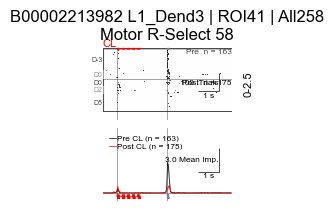

Adding anmIdx 16 B00002213982 dendrites ROI_score 1 ROI3 ROI_idx 41 pg258...nRows: 2, nCols: 2, nPlots 1, figSize: (3.0, 2)
Current plotminVal: -0.081 plotmaxVal: 7.940 plotShift: [0.]
Applying Manual Plot Limits
Final plotminVal: -1.000 final_plotmaxVal: 8.000 final_plotShift: [0]
Finished!


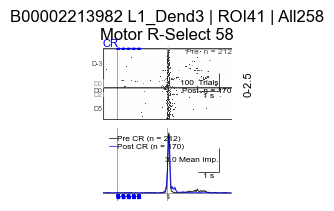

Adding anmIdx 3 B00002213772 somas ROI_score 1 ROI11 ROI_idx 11 pg100...nRows: 2, nCols: 2, nPlots 1, figSize: (3.0, 2)
Current plotminVal: -0.005 plotmaxVal: 0.371 plotShift: [0.]
Applying Manual Plot Limits
Final plotminVal: -0.500 final_plotmaxVal: 3.500 final_plotShift: [0]
Finished!


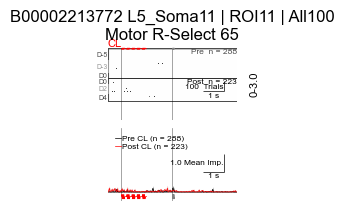

Adding anmIdx 3 B00002213772 somas ROI_score 1 ROI11 ROI_idx 11 pg100...nRows: 2, nCols: 2, nPlots 1, figSize: (3.0, 2)
Current plotminVal: -0.035 plotmaxVal: 3.339 plotShift: [0.]
Applying Manual Plot Limits
Final plotminVal: -0.500 final_plotmaxVal: 3.500 final_plotShift: [0]
Finished!


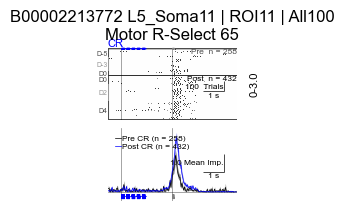

In [5]:
# Same panels as the Fig6_examples.pdf cell above, but driven entirely off the loaded repo
# data (all_grouped_aligned_traces_repo / summaryInfo_repo) — compare the two PDFs to confirm the
# export round-tripped.
figParams['cueInfo'] = cueInfo_repo
# keep the display mode the examples cell set ('preShiftOnly_byTtype' etc. resolve to the stored
# 'byPrePost_byTtype' branch); only fall back if the repo data does not hold what it reads
if jsm.resolve_align_trace_type(figParams['trialGrouping'])[0] not in repo_trace_types:
    print(f"figParams['trialGrouping'] {figParams['trialGrouping']!r} is not in the repo data "
          f"{repo_trace_types}; falling back to {repo_trace_types[0]!r}")
    figParams['trialGrouping'] = repo_trace_types[0]
figName = 'Fig6_examples_fromRepoData.pdf'
figParams['plot_figSummary_label'] = ps
figParams['export_ttypes'] = ['CL','CR'] 
figParams['export_ttype_colors'] = [(1,0,0),(0,0,1)]
figParams['scaling_ttypes'] = ['CL','CR']         
figParams['autoScale_ttypes'] = figParams['scaling_ttypes']
figParams['autoScale_be_ttypes'] = figParams['scaling_ttypes']
figParams['filt_trace_byTrial'] = False
figParams['filt_trace_byTrial_window'] = {}
figParams['filt_trace_byTrial_window']['allTC_dffbc_decon_sp_events_MatchDx2Sx1'] = {}
figParams['filt_trace_byTrial_window']['allTC_dffbc_decon_sp_events_MatchDx2Sx1']['dendrites'] = 3
figParams['filt_trace_byTrial_window']['allTC_dffbc_decon_sp_events_MatchDx2Sx1']['somas'] = 3
figParams['horzScalar_im_zoom'] = 1.5
figParams['vertScalar_im_zoom'] = 1
figParams['wspace'] = 0
figParams['hspace'] = 0
figParams['manual_plotmaxVal'] = {}
figParams['manual_plotminVal'] = {}
figParams['manual_plotShift'] = {}
figParams['splitPrePost'] = False
figParams['export_byPrePost_ttype_colors'] = {}
figParams['export_byPrePost_ttype_colors']['preShift'] = [(0.5,0.5,0.5),(0.5,0.5,0.5)]
figParams['export_byPrePost_ttype_colors']['postShift'] = [(1,0,0),(0,0,1)]
figParams['export_byPrePost_ttype_linewidth'] = {}
figParams['export_byPrePost_ttype_linewidth']['preShift'] = [0.5,0.5]
figParams['export_byPrePost_ttype_linewidth']['postShift'] = [0.5,0.5]
figParams['export_byPrePost_ttype_linestyle'] = {}
figParams['export_byPrePost_ttype_linestyle']['preShift'] = [':',':']
figParams['export_byPrePost_ttype_linestyle']['postShift'] = ['-','-']
figParams['export_byPrePost_ttype_dashes'] = {}
figParams['export_byPrePost_ttype_dashes']['preShift'] = [(0.5,0.5),(0.5,0.5)]
figParams['export_byPrePost_ttype_dashes']['postShift'] = [None, None]
figParams['plot_horzCueLocation'] = 'bottom'
figParams['im_horzCueLocation'] = 'top'
figParams['plot_y0'] = 0.0
figParams['plot_height'] = 0.15
figParams['preview_figs'] = False
saveFigs = PDF_export_active
verbose =True
print(f'FIG_EXPORT_DIR = {FIG_EXPORT_DIR}')
print(f'figName = {figName}')
with maybe_pdf(os.path.join(FIG_EXPORT_DIR,figName)) as pdf:
    for e,entry in enumerate(ROI_manifest):
        if entry['ROI_type_key'] == 'dendrites':
            ROI_type_key = 'dendrites'
            ROI_score = 1
            c = 4
            r = 58
            figParams['max_nTrials_display'] = 392
            figParams['nSpacers'] = 4
            figParams['manual_plotLims'] = True
            figParams['manual_plotmaxVal'][ROI_type_key] = 8
            figParams['manual_plotminVal'][ROI_type_key] = -1
            figParams['manual_plotShift'][ROI_type_key] = [0]
            figParams['manual_imCont'] = True
            figParams['manual_max_imCont'] = {}
            figParams['manual_min_imCont'] = {}
            figParams['manual_max_imCont'][ROI_type_key] = 2.5
            figParams['manual_min_imCont'][ROI_type_key] = 0

            figParams['export_ttypes'] = ['CL'] 
            figParams['export_ttype_colors'] = [(1,0,0)]
            figParams['export_byPrePost_ttype_colors'] = {}
            figParams['export_byPrePost_ttype_colors']['preShift'] = [(0,0,0)]
            figParams['export_byPrePost_ttype_colors']['postShift'] = [(1,0,0)]
            figParams['export_byPrePost_ttype_linewidth'] = {}
            figParams['export_byPrePost_ttype_linewidth']['preShift'] = [0.5,0.5]
            figParams['export_byPrePost_ttype_linewidth']['postShift'] = [0.5,0.5]
            figParams['export_byPrePost_ttype_linestyle'] = {}
            figParams['export_byPrePost_ttype_linestyle']['preShift'] = ['-','-']
            figParams['export_byPrePost_ttype_linestyle']['postShift'] = ['-','-']
            figParams['export_byPrePost_ttype_dashes'] = {}
            figParams['export_byPrePost_ttype_dashes']['preShift'] = [None, None]
            figParams['export_byPrePost_ttype_dashes']['postShift'] = [None, None]
            
            pdf = jsm.trial_alignments_byROI_pages(pdf, summaryInfo_repo, \
                all_grouped_aligned_traces_repo[figParams['examples_group']]['grouped_aligned_traces'][align_data]['traceAlignParams'],\
                all_grouped_aligned_traces_repo[figParams['examples_group']]['grouped_aligned_traces'][align_data]['aligned_traces'], \
                figParams, figParams['trialGrouping'], align_data, zoom, figParams['export_ttypes'], \
                entry['ROI_score'], entry['ROI_type_key'], entry['anmIdx'], entry['anm'], entry['ROI_idx'], \
                entry['page_count'], entry['cluster_label'], entry['cluster_idx'], saveFigs, verbose)
            figParams['export_ttypes'] = ['CR'] 
            figParams['export_ttype_colors'] = [(0,0,1)]
            figParams['export_byPrePost_ttype_colors'] = {}
            figParams['export_byPrePost_ttype_colors']['preShift'] = [(0,0,0)]
            figParams['export_byPrePost_ttype_colors']['postShift'] = [(0,0,1)]
            figParams['export_byPrePost_ttype_linewidth'] = {}
            figParams['export_byPrePost_ttype_linewidth']['preShift'] = [0.5,0.5]
            figParams['export_byPrePost_ttype_linewidth']['postShift'] = [0.5,0.5]
            figParams['export_byPrePost_ttype_linestyle'] = {}
            figParams['export_byPrePost_ttype_linestyle']['preShift'] = ['-','-']
            figParams['export_byPrePost_ttype_linestyle']['postShift'] = ['-','-']
            figParams['export_byPrePost_ttype_dashes'] = {}
            figParams['export_byPrePost_ttype_dashes']['preShift'] = [None, None]
            figParams['export_byPrePost_ttype_dashes']['postShift'] = [None, None]
            pdf = jsm.trial_alignments_byROI_pages(pdf, summaryInfo_repo, \
                all_grouped_aligned_traces_repo[figParams['examples_group']]['grouped_aligned_traces'][align_data]['traceAlignParams'],\
                all_grouped_aligned_traces_repo[figParams['examples_group']]['grouped_aligned_traces'][align_data]['aligned_traces'], \
                figParams, figParams['trialGrouping'], align_data, zoom, figParams['export_ttypes'], \
                entry['ROI_score'], entry['ROI_type_key'], entry['anmIdx'], entry['anm'], entry['ROI_idx'], \
                entry['page_count'], entry['cluster_label'], entry['cluster_idx'], saveFigs, verbose)
        else:
    
            
            ROI_type_key = 'somas'
            ROI_score = 1
            c = 4
            r = 65
            figParams['max_nTrials_display'] = 710
            figParams['nSpacers'] = 7
            figParams['manual_plotLims'] = True
            figParams['manual_plotmaxVal'][ROI_type_key] = 3.5
            figParams['manual_plotminVal'][ROI_type_key] = -0.5
            figParams['manual_plotShift'][ROI_type_key] = [0]
            figParams['manual_imCont'] = True
            figParams['manual_max_imCont'] = {}
            figParams['manual_min_imCont'] = {}
            figParams['manual_max_imCont'][ROI_type_key] = 3
            figParams['manual_min_imCont'][ROI_type_key] = 0
            figParams['export_ttypes'] = ['CL'] 
            figParams['export_ttype_colors'] = [(1,0,0)]
            figParams['export_byPrePost_ttype_colors'] = {}
            figParams['export_byPrePost_ttype_colors']['preShift'] = [(0,0,0)]
            figParams['export_byPrePost_ttype_colors']['postShift'] = [(1,0,0)]
            figParams['export_byPrePost_ttype_linewidth'] = {}
            figParams['export_byPrePost_ttype_linewidth']['preShift'] = [0.5,0.5]
            figParams['export_byPrePost_ttype_linewidth']['postShift'] = [0.5,0.5]
            figParams['export_byPrePost_ttype_linestyle'] = {}
            figParams['export_byPrePost_ttype_linestyle']['preShift'] = ['-','-']
            figParams['export_byPrePost_ttype_linestyle']['postShift'] = ['-','-']
            figParams['export_byPrePost_ttype_dashes'] = {}
            figParams['export_byPrePost_ttype_dashes']['preShift'] = [None, None]
            figParams['export_byPrePost_ttype_dashes']['postShift'] = [None, None]
            
            pdf = jsm.trial_alignments_byROI_pages(pdf, summaryInfo_repo, \
                all_grouped_aligned_traces_repo[figParams['examples_group']]['grouped_aligned_traces'][align_data]['traceAlignParams'],\
                all_grouped_aligned_traces_repo[figParams['examples_group']]['grouped_aligned_traces'][align_data]['aligned_traces'], \
                figParams, figParams['trialGrouping'], align_data, zoom, figParams['export_ttypes'], \
                entry['ROI_score'], entry['ROI_type_key'], entry['anmIdx'], entry['anm'], entry['ROI_idx'], \
                entry['page_count'], entry['cluster_label'], entry['cluster_idx'], saveFigs, verbose)
            figParams['export_ttypes'] = ['CR'] 
            figParams['export_ttype_colors'] = [(0,0,1)]
            figParams['export_byPrePost_ttype_colors'] = {}
            figParams['export_byPrePost_ttype_colors']['preShift'] = [(0,0,0)]
            figParams['export_byPrePost_ttype_colors']['postShift'] = [(0,0,1)]
            figParams['export_byPrePost_ttype_linewidth'] = {}
            figParams['export_byPrePost_ttype_linewidth']['preShift'] = [0.5,0.5]
            figParams['export_byPrePost_ttype_linewidth']['postShift'] = [0.5,0.5]
            figParams['export_byPrePost_ttype_linestyle'] = {}
            figParams['export_byPrePost_ttype_linestyle']['preShift'] = ['-','-']
            figParams['export_byPrePost_ttype_linestyle']['postShift'] = ['-','-']
            figParams['export_byPrePost_ttype_dashes'] = {}
            figParams['export_byPrePost_ttype_dashes']['preShift'] = [None, None]
            figParams['export_byPrePost_ttype_dashes']['postShift'] = [None, None]
            pdf = jsm.trial_alignments_byROI_pages(pdf, summaryInfo_repo, \
                all_grouped_aligned_traces_repo[figParams['examples_group']]['grouped_aligned_traces'][align_data]['traceAlignParams'],\
                all_grouped_aligned_traces_repo[figParams['examples_group']]['grouped_aligned_traces'][align_data]['aligned_traces'], \
                figParams, figParams['trialGrouping'], align_data, zoom, figParams['export_ttypes'], \
                entry['ROI_score'], entry['ROI_type_key'], entry['anmIdx'], entry['anm'], entry['ROI_idx'], \
                entry['page_count'], entry['cluster_label'], entry['cluster_idx'], saveFigs, verbose)



# Load all data

In [6]:
#IMPORTANT Load the masterData dictionary, preferably from the data repo reduced file size versions
masterData = jsm.masterData_loading(DATA_DIR)
# mdDir = '/home/range6-raid3/scheij/Documents/Data/mainDS'
# mdTitle = 'allSlim3'
# masterData = pickle.load(open(fr'{mdDir}/{mdTitle}.p', 'rb'))

#General params
trialStart = 0.15
sampleEnd = trialStart+1.2
delayEnd = sampleEnd+1.25
anatKeys = ['dendrites', 'somas']
frs = [44.6, 22.8]
anms = list(masterData.keys())


--------------------------
Loading data for B00002121749...
Loading behavior data for B00002121749...
Loading shiftInfo data for B00002121749...
Loading somas data for B00002121749...
  Path: /export/general/pooledData/Jackson/repo_data/B00002121749/somas
  File: B00002121749_somas.pkl
  FileSize:      0.0 GB (0.0 GiB)
  Last Modified: 2026-08-14 11:38:51.581717
  Loading B00002121749_somas.pkl from /export/general/pooledData/Jackson/repo_data/B00002121749/somas...Finished!
  Loading Took a total of : 0.0 min
Loading session 0 data for B00002121749...
  Path: /export/general/pooledData/Jackson/repo_data/B00002121749/somas
  File: B00002121749_somas_session_0.pkl
  FileSize:      0.04 GB (0.04 GiB)
  Last Modified: 2026-08-14 11:38:51.759717
  Loading B00002121749_somas_session_0.pkl from /export/general/pooledData/Jackson/repo_data/B00002121749/somas...Finished!
  Loading Took a total of : 0.0 min
Loading session 1 data for B00002121749...
  Path: /export/general/pooledData/Jackson/rep

In [7]:
dffKey = 'impulse_trace'##'consensus_NMFtc_dff_bc_decon_sp'#'consensus_NMFtc_dff_bc'
dffKeys = ['impulse_trace']#['consensus_NMFtc_dff_bc_decon_sp', 'consensus_NMFtc_dff_bc', 'impulse_trace']
maskKey = 'trace_mask'

# factors = [10,5]
factors = [22,11]
Z = 'std_only'
phases2 = ['pre', 'preShift_early', 'preShift_late', 'post', 'late', 'day-1_beg', 'day-1_mid', 'day-1_end', 'shiftDay_post', 'shiftDay_pre', 'early'] 
windowSize = [-3.6,3.6]
allAnmParams = jsm.get_allAnmParams(masterData, anms, frs, factors, Z, phases2, dffKeys, maskKey=maskKey, windowSize = windowSize)

0 B00002121749
Getting params for somas impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
relDays: [-8 -2  0  2  5]
phase: preShift_late, days used: [-2  0]
phase: early, days used: [0, 2]
1 B00002121774
Getting params for dendrites impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
Getting params for somas impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
<<WARNING>> [tsep_traces()] B00002121774 07-Oct-2022 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002121774 sess0 07-Oct-2022 len(trial_frames) = 305 len(tsep_sess) = 306
<<WARNING>> [tsep_traces()] B00002121774 09-Oct-2022 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002121774 sess1 09-Oct-2022 len(trial_frames) = 284 len(tsep_sess) = 285
relDays: [-6 -5 

/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/functions/js_manuscript_final.py:2555: RuntimeWarning: All-NaN slice encountered
  closestDist.append(np.nanmin(tDist))


2 B00002121777
Getting params for dendrites impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
<<WARNING>> [tsep_traces()] B00002121777 221008 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002121777 sess1 221008 len(trial_frames) = 374 len(tsep_sess) = 375
Getting params for somas impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
<<WARNING>> [tsep_traces()] B00002121777 221009 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002121777 sess1 221009 len(trial_frames) = 293 len(tsep_sess) = 294
<<WARNING>> [tsep_traces()] B00002121777 221013 IGNORING SESSION
            KNOWN ISSUE ignore_session 294
            KNOWN ISSUE description imaging issues
<<WARNING>> [get_tsep_wFlag()] B00002121777 sess2 221013 len(trial_frames) = 127

/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/functions/js_manuscript_final.py:2555: RuntimeWarning: All-NaN slice encountered
  closestDist.append(np.nanmin(tDist))


6 B00002213785
Getting params for dendrites impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
<<WARNING>> [tsep_traces()] B00002213785 230131 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002213785 sess2 230131 len(trial_frames) = 212 len(tsep_sess) = 213
Getting params for somas impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
<<WARNING>> [tsep_traces()] B00002213785 230203 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002213785 sess3 230203 len(trial_frames) = 253 len(tsep_sess) = 254
relDays: [-5 -4 -2 -1  0  1  2  3  4]
phase: preShift_early, days used: [-4 -2]
phase: preShift_late, days used: [-1  0]
phase: late, days used: [2 3]
phase: early, days used: [0, 1]


/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/functions/js_manuscript_final.py:2555: RuntimeWarning: All-NaN slice encountered
  closestDist.append(np.nanmin(tDist))


7 B00002213889
Getting params for dendrites impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
Getting params for somas impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
relDays: [-4 -3 -2 -1  0  1  2]
phase: preShift_early, days used: [-3 -2]
phase: preShift_late, days used: [-1  0]
phase: early, days used: [0, 1]
8 B00002213908
Getting params for dendrites impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
Getting params for somas impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
relDays: [-4 -3 -2 -1  0  1  2  4  5]
phase: preShift_early, days used: [-3 -2]
phase: preShift_late, days used: [-1  0]
phase: late, days used: [2 4]
phase: early, days used: [0, 1]
9 B00002213909
Getting params for dendrites impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
Getting params for somas impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
relDays: [-7 -6 -4 -3 -2]
phase: preShift_early, days used: [-6 -4]
phase: preS

/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/functions/js_manuscript_final.py:2555: RuntimeWarning: All-NaN slice encountered
  closestDist.append(np.nanmin(tDist))


# pre post

### preCalc

In [8]:

thrsh = 0.05
minTrials = 10
anatKeys = ['dendrites', 'somas']

aAnms, keepRoisFull, keepRoisDS, allNaNs = jsm.check_anms_ROIs(allAnmParams, anms, anatKeys, dffKey, thrsh)
aAnms, iAnms, anmsMinTrial, allMinTrials = jsm.check_trials(allAnmParams, anms, anatKeys, dffKey, minTrials)

full
dendrites 331 / 402 0.823
somas 483 / 528 0.915

dendrites B00002121774 334 264 74 15
dendrites B00002213772 350 361 34 72
dendrites B00002213773 190 196 32 67
dendrites B00002213784 308 260 20 23
dendrites B00002213785 271 264 43 68
dendrites B00002213908 266 242 43 41
dendrites B00002213909 337 306 142 47
dendrites B00002213921 254 301 51 47
dendrites B00002213943 311 340 24 50
dendrites B00002213998 366 28 148 17
somas B00002121749 164 41 45 15
somas B00002121774 238 229 58 35
somas B00002213772 258 288 25 74
somas B00002213773 107 80 18 19
somas B00002213785 235 250 25 49
somas B00002213889 321 229 59 22
somas B00002213908 270 227 103 73
somas B00002213909 251 198 142 18
somas B00002213921 281 290 23 20
somas B00002213943 286 275 29 20
somas B00002213997 187 83 256 18
somas B00002213999 287 207 15 12
12
Finished processing trials.


In [9]:
shiftAnms = {}
for anat in anatKeys:
    shiftAnms[anat] = []
    for anm in anms:
        if anat in list(allAnmParams[anm][dffKey]['dsTsep'].keys()):
            tracker = allAnmParams[anm]['tracker']
            dendDays = allAnmParams[anm]['dendDays']
            if anat == 'dendrites':
                anatMask = dendDays
            else:
                anatMask = ~dendDays
            sessions = np.unique(tracker[anatMask,0])
            if 0 in sessions:
                shiftAnms[anat].append(anm)
                print(f'{anm} {anat} {sessions} SHIFT DAY')


B00002121774 dendrites [-6 -4  0  2] SHIFT DAY
B00002121777 dendrites [-6 -4  0  2 10] SHIFT DAY
B00002213784 dendrites [-6 -3  0  2  4] SHIFT DAY
B00002213785 dendrites [-5 -2  0  2  4] SHIFT DAY
B00002213921 dendrites [-6 -4  0] SHIFT DAY
B00002213932 dendrites [-8 -6 -2  0  1] SHIFT DAY
B00002213943 dendrites [-4 -2  0  2] SHIFT DAY
B00002213944 dendrites [-3  0] SHIFT DAY
B00002213970 dendrites [-10  -8  -3   0   1   2   3   5] SHIFT DAY
B00002213982 dendrites [-3  0  2  5] SHIFT DAY
B00002213985 dendrites [-8 -2  0  3] SHIFT DAY
B00002213997 dendrites [-3 -1  0  2  4] SHIFT DAY
B00002213998 dendrites [-3 -2 -1  0  1  2  3] SHIFT DAY
B00002213999 dendrites [-4 -2  0  2  4] SHIFT DAY
B00002121749 somas [-8 -2  0  2  5] SHIFT DAY
B00002213772 somas [-5 -3  0  2  4] SHIFT DAY
B00002213889 somas [-4 -2  0  2] SHIFT DAY
B00002213908 somas [-4 -2  0  2  5] SHIFT DAY
B00002213920 somas [-5 -2  0  2] SHIFT DAY
B00002214001 somas [-3 -1  0  2  4] SHIFT DAY


In [10]:

iAnms = {}
aAnms = {}
minTrials = 100
anmsMinTrial = {}
for anat in anatKeys:
    iAnms[anat] = []
    aAnms[anat] = []
    anmsMinTrial[anat] = {}
    for anm in anms:
        if anat in list(allAnmParams[anm][dffKey]['dsTsep'].keys()):
            aAnms[anat].append(anm)
            tracker = allAnmParams[anm]['tracker']
            dendDays = allAnmParams[anm]['dendDays']
            preMask = allAnmParams[anm]['shiftMask']['pre']
            postMask = allAnmParams[anm]['shiftMask']['post']
            earlyMask = allAnmParams[anm]['shiftMask']['early']
            lateMask = allAnmParams[anm]['shiftMask']['late']
            me = allAnmParams[anm]['me']
            de = allAnmParams[anm]['de']

            if anat == 'dendrites':
                anatMask = dendDays
            else:
                anatMask = ~dendDays

            preAnatMask = np.logical_and(anatMask, preMask)
            postAnatMask = np.logical_and(anatMask, postMask)
            pretkr = tracker[preAnatMask,:]
            posttkr = tracker[postAnatMask,:]
            pCR = np.sum(posttkr[:,2]==0)
            pCL = np.sum(posttkr[:,2]==1)
            preCR = np.sum(pretkr[:,2]==0)
            preCL = np.sum(pretkr[:,2]==1)
            ftsep = allAnmParams[anm][dffKey]['fullTsep'][anat]['full']
            dsTsep = allAnmParams[anm][dffKey]['dsTsep'][anat]['full']

            if np.all(np.hstack([item>minTrials for item in [pCR, pCL, preCR, preCL]])):
                if anm != 'B00002121777':
                    if ftsep.shape[1]>=10:
                        iAnms[anat].append(anm)
                        print(anat, anm, np.sum(pCR),np.sum(pCL))
                        anmsMinTrial[anat][anm] = np.min(np.hstack([pCR, pCL, preCR, preCL]))
print(iAnms)

dendrites B00002121774 295 244
dendrites B00002213772 311 199
dendrites B00002213784 377 254
dendrites B00002213785 166 141
dendrites B00002213908 178 138
dendrites B00002213920 245 226
dendrites B00002213932 253 210
dendrites B00002213970 130 294
dendrites B00002213982 170 175
dendrites B00002213985 248 250
dendrites B00002213997 228 177
dendrites B00002213999 365 268
somas B00002121774 237 224
somas B00002213772 432 223
somas B00002213784 243 180
somas B00002213785 166 140
somas B00002213889 226 139
somas B00002213908 336 222
somas B00002213920 229 199
somas B00002213982 225 200
somas B00002213999 276 190
somas B00002214001 161 199
{'dendrites': ['B00002121774', 'B00002213772', 'B00002213784', 'B00002213785', 'B00002213908', 'B00002213920', 'B00002213932', 'B00002213970', 'B00002213982', 'B00002213985', 'B00002213997', 'B00002213999'], 'somas': ['B00002121774', 'B00002213772', 'B00002213784', 'B00002213785', 'B00002213889', 'B00002213908', 'B00002213920', 'B00002213982', 'B0000221399

In [11]:
iAnms2 = {}
aAnms2 = {}
minTrials = 10
for anat in anatKeys:
    iAnms2[anat] = []
    aAnms2[anat] = []
    for anm in anms:
        if anat in list(allAnmParams[anm][dffKey]['dsTsep'].keys()):
            aAnms2[anat].append(anm)
            tracker = allAnmParams[anm]['tracker']
            dendDays = allAnmParams[anm]['dendDays']
            cTimes = allAnmParams[anm]['cTimes']
            goCues = allAnmParams[anm]['goCues']
            preMask = allAnmParams[anm]['shiftMask']['pre']
            postMask = allAnmParams[anm]['shiftMask']['post']
            earlyMask = allAnmParams[anm]['shiftMask']['early']
            lateMask = allAnmParams[anm]['shiftMask']['late']
            me = allAnmParams[anm]['me']
            de = allAnmParams[anm]['de']
            ar = allAnmParams[anm]['afterRight']
            al = allAnmParams[anm]['afterLeft']
            an = allAnmParams[anm]['afterNone']
            ln = np.logical_or(al, an)

            if anat == 'dendrites':
                anatMask = dendDays
            else:
                anatMask = ~dendDays

            preAnatMask = np.logical_and(anatMask, preMask)
            postAnatMask = np.logical_and(anatMask, postMask)
            pretkr = tracker[preAnatMask,:]
            posttkr = tracker[postAnatMask,:]
            postME = me[postAnatMask]
            postDE = de[postAnatMask]
            postAR = ar[postAnatMask]
            postAL = al[postAnatMask]
            postAN = an[postAnatMask]
            postLN = ln[postAnatMask]
            
            pCR = np.sum(posttkr[:,2]==0)
            pCL = np.sum(posttkr[:,2]==1)
            pMER = np.sum(np.logical_and(postME, posttkr[:,2]==5))
            pDER = np.sum(np.logical_and(postDE, posttkr[:,2]==5))
            pAR = np.sum(postAR)
            pAL = np.sum(postAL)
            pAN = np.sum(postAN)
            pNL = np.sum(postLN)
            
            ftsep = allAnmParams[anm][dffKey]['fullTsep'][anat]['full']
            dsTsep = allAnmParams[anm][dffKey]['dsTsep'][anat]['full']

            if pAR>minTrials and pCR>minTrials:# and pAL>minTrials:# and anmLearn[anm]==(1,0,0):
            #if pMER>minTrials and pCR>minTrials:
                if anm != 'B00002121777':
                    if ftsep.shape[1]>=10:
                        iAnms2[anat].append(anm)
                        print(anat, anm, np.sum(pAR), np.sum(pAL), np.sum(pCR))


dendrites B00002121774 93 4 295
dendrites B00002213772 31 17 311
dendrites B00002213784 26 5 377
dendrites B00002213785 44 17 166
dendrites B00002213908 36 42 178
dendrites B00002213932 66 19 253
dendrites B00002213970 269 195 130
dendrites B00002213982 176 98 170
dendrites B00002213997 295 35 228
dendrites B00002213998 202 50 233
dendrites B00002213999 86 54 365
somas B00002121749 25 25 113
somas B00002121774 160 17 237
somas B00002213772 29 35 432
somas B00002213784 28 8 243
somas B00002213889 16 7 226
somas B00002213908 53 21 336
somas B00002213982 108 5 225
somas B00002213985 29 4 143
somas B00002213997 124 14 169
somas B00002213999 47 64 276
somas B00002214001 78 32 161


In [12]:
bothAnms = {}
bothANDshiftAnms = {}
for ak, anat in enumerate(anatKeys):
    anms1 = iAnms[anat]
    anms2 = iAnms2[anat]
    anms3 = shiftAnms[anat]
    common_animals = set(anms1) & set(anms2) & set(anms3)
    count = len(common_animals)

    print(anat, f'MER {len(anms1)}', f'Motor {len(anms2)}', f'SHIFT Day {len(anms3)}',\
          f'Both {np.sum(np.isin(anms1, anms2))}', f'BOTH AND SHIFT Day {count}')
    bothAnms[anat] = np.hstack(anms1)[np.isin(anms1, anms2)]
    bothANDshiftAnms[anat] = common_animals

print(bothAnms)
print(bothANDshiftAnms)

dendrites MER 12 Motor 11 SHIFT Day 14 Both 10 BOTH AND SHIFT Day 8
somas MER 10 Motor 11 SHIFT Day 6 Both 8 BOTH AND SHIFT Day 4
{'dendrites': array(['B00002121774', 'B00002213772', 'B00002213784', 'B00002213785',
       'B00002213908', 'B00002213932', 'B00002213970', 'B00002213982',
       'B00002213997', 'B00002213999'], dtype='<U12'), 'somas': array(['B00002121774', 'B00002213772', 'B00002213784', 'B00002213889',
       'B00002213908', 'B00002213982', 'B00002213999', 'B00002214001'],
      dtype='<U12')}
{'dendrites': {'B00002213784', 'B00002213982', 'B00002213970', 'B00002213932', 'B00002213785', 'B00002213999', 'B00002213997', 'B00002121774'}, 'somas': {'B00002213908', 'B00002214001', 'B00002213889', 'B00002213772'}}


In [13]:
psWindow = [-3.6,3.6]
useDS = True

#anmsToUse = iAnms
anmsToUse = bothAnms
shuffAnms = True
shuffRois = False
enforceMinTrial = True
binary = False

allAnms = np.unique(np.hstack([anmsToUse[anat] for anat in anatKeys]))
phases = ['pre', 'post']
pLabels = ['pre', 'post']
# phases = ['pre', 'early']
# pLabels = ['pre', 'early']
mods = ['GO','CT']#,'errGO', 'errCT']
alignTimes = ['goCues','cTimes']#,'goCues','cTimes']

nBoot = 10000
megaTseps = {}
megaTsepsHH = {}
emptyMegaTsep = {'dendrites': [], 'somas': []}

for p, phase in enumerate(phases):
    megaTseps[phase] = {}
    megaTsepsHH[f'{phase}1'] = {}
    megaTsepsHH[f'{phase}2'] = {}
    for mod in mods:
        megaTseps[phase][mod] = copy.deepcopy(emptyMegaTsep)
        megaTsepsHH[f'{phase}1'][mod] = copy.deepcopy(emptyMegaTsep)
        megaTsepsHH[f'{phase}2'][mod] = copy.deepcopy(emptyMegaTsep)

#making holder matracies
somaTime = allAnmParams[anmsToUse['somas'][0]][dffKey]['dsTsep']['somas']['go-psTsep'].shape[2]
nSoma = 0
for anm in anmsToUse['somas']:
    nSoma+=allAnmParams[anm][dffKey]['dsTsep']['somas']['go-psTsep'][:,keepRoisDS['somas'][anm],:].shape[1]
    
dendTime = allAnmParams[anmsToUse['dendrites'][0]][dffKey]['dsTsep']['dendrites']['go-psTsep'].shape[2]
nDend = 0
for anm in anmsToUse['dendrites']:
    nDend+=allAnmParams[anm][dffKey]['dsTsep']['dendrites']['go-psTsep'][:,keepRoisDS['dendrites'][anm],:].shape[1]

somaEmpty = np.empty([4, somaTime, nSoma, nBoot])
dendEmpty = np.empty([4, dendTime, nDend, nBoot])
empties = [dendEmpty, somaEmpty]
for phase in phases:
    for mod in mods:
        for ak, anat in enumerate(anatKeys):
            megaTseps[phase][mod][anat] = copy.deepcopy(empties[ak])
            megaTsepsHH[f'{phase}1'][mod][anat] = copy.deepcopy(empties[ak])
            megaTsepsHH[f'{phase}2'][mod][anat] = copy.deepcopy(empties[ak])    
for i in tqdm(range(nBoot)):
    for ak, anat in enumerate(anatKeys):
        if shuffAnms:
            anmIdxs = np.random.choice(np.arange(len(anmsToUse[anat])), len(anmsToUse[anat]))
        else:
            anmIdxs = np.arange(len(anmsToUse[anat]))
        nRois = np.sum(np.hstack([np.sum(keepRoisDS[anat][anm]) for anm in anmsToUse[anat]]))
        for m, mod in enumerate(mods):
            if 'err' in mod:
                returnErrors = True
            else:
                returnErrors = False
            
            mT = jsm.gather_anmShuff_megaTsepFull(allAnmParams, anat, ak, mod, phases, frs, keepRoisDS, dffKey, alignTimes[m], anmsToUse, nRois,
                                                  anmIdxs, enforceMinTrial, binary, returnErrors, anmsMinTrial)
            
            mT1, mT2 = jsm.gather_anmShuff_megaTsepHH(allAnmParams, anat, ak, mod, phases, frs,  keepRoisDS, dffKey, alignTimes[m], anmsToUse, nRois,
                                                  anmIdxs, enforceMinTrial, binary, returnErrors, anmsMinTrial)
            for phase in phases:
                megaTseps[phase][mod][anat][:,:,:,i] = mT[phase]
                megaTsepsHH[f'{phase}1'][mod][anat][:,:,:,i] = mT1[phase]
                megaTsepsHH[f'{phase}2'][mod][anat][:,:,:,i] = mT2[phase]

  0%|          | 0/10000 [00:00<?, ?it/s]

In [14]:
for ak, anat in enumerate(anatKeys):
    print(anat, megaTsepsHH[f'{phases[0]}2'][mod][anat].shape)

dendrites (4, 16, 169, 10000)
somas (4, 16, 180, 10000)


In [15]:
for anat in anatKeys:
    print(anat, len(bothAnms[anat]))

dendrites 10
somas 8


In [16]:
nBoot = 10000

allAnmCDs = {}
allAnmDenoms = {}
allAnmIdxs = {}
takeEqualTrials = True
anmsToUse = bothAnms
#nTriToGrab = 100
for ak, anat in enumerate(anatKeys):
    allAnmCDs[anat] = {}
    allAnmDenoms[anat] = {}
    allAnmIdxs[anat] = []
    F = frs[ak]/factors[ak]
    for a, anm in enumerate(anmsToUse[anat]):
        nROI = np.sum(keepRoisDS[anat][anm])
        allAnmIdxs[anat].append(np.ones(nROI)*a)
        #anm = iAnms[anat][0]
        allAnmCDs[anat][anm] = {}
        allAnmDenoms[anat][anm] = {}
        nTriToGrab=[]
        for phase in ['pre','post']:
    
            anmData = allAnmParams[anm]
            tsep = anmData[dffKey]['dsTsep'][anat]['go-psTsep']
            sMask = anmData['shiftMask'][phase]
            dd = anmData['dendDays']
            if anat == 'dendrites':
                anatMask = dd
            else:
                anatMask = ~dd
            tracker = anmData['tracker']
            fullMask = np.logical_and(anatMask, sMask)
            roiMask = keepRoisDS[anat][anm]
            
            pTkr = tracker[fullMask,:]
            crM = pTkr[:,2]==0
            crT = np.where(crM)[0]

            clM = pTkr[:,2]==1
            clT = np.where(clM)[0]
            
            pTsep = tsep[fullMask[anatMask],:,:]
            pTsep = pTsep[:,roiMask,:]

            nTriToGrab.append(np.min([np.sum(clM), np.sum(crM)]))
        nTriToGrab=np.min(nTriToGrab)
        
        for phase in ['pre','post']:
    
            anmData = allAnmParams[anm]
            tsep = anmData[dffKey]['dsTsep'][anat]['go-psTsep']
            sMask = anmData['shiftMask'][phase]
            dd = anmData['dendDays']
            if anat == 'dendrites':
                anatMask = dd
            else:
                anatMask = ~dd
            tracker = anmData['tracker']
            fullMask = np.logical_and(anatMask, sMask)
            roiMask = keepRoisDS[anat][anm]
            
            pTkr = tracker[fullMask,:]
            crM = pTkr[:,2]==0
            crT = np.where(crM)[0]

            clM = pTkr[:,2]==1
            clT = np.where(clM)[0]
            
            pTsep = tsep[fullMask[anatMask],:,:]
            pTsep = pTsep[:,roiMask,:]            
            CDs = []
            denoms = []
            for i in range(nBoot):
                if takeEqualTrials:
                    bCRm = np.random.choice(crT, nTriToGrab)
                    bCLm = np.random.choice(clT, nTriToGrab)
                else:
                    bCLm = np.random.choice(clT, len(clT))
                    bCRm = np.random.choice(crT, len(crT))
                CR = np.nanmean(pTsep[bCRm,:,:], axis = 0)
                CL = np.nanmean(pTsep[bCLm,:,:], axis = 0)
                denom = np.abs((np.nanmean(pTsep[bCRm,:,:],axis = 0))+np.abs(np.nanmean(pTsep[bCLm,:,:],axis = 0)))
                cd = (CR-CL)/denom
                CDs.append(cd)
                denoms.append(denom)
            CDs = np.stack(CDs)
            denoms = np.stack(denoms)#boot x roi x time
            allAnmCDs[anat][anm][phase] = CDs
            allAnmDenoms[anat][anm][phase] = denoms
    allAnmIdxs[anat] = np.hstack(allAnmIdxs[anat])

/tmp/ipykernel_1194786/1278169761.py:83: RuntimeWarning: invalid value encountered in divide
  cd = (CR-CL)/denom


In [17]:
import matplotlib.colors as mcolors
import numpy as np

def adjust(color, factor):
    rgb = np.array(mcolors.to_rgb(color))
    return np.clip(rgb * factor, 0, 1)
def mix_with_white(color, alpha):
    rgb = np.array(mcolors.to_rgb(color))
    return alpha * rgb + (1 - alpha) * np.ones(3)
COLORS = {
    # base hues
    'L_base': mcolors.to_rgb('#d62728'),  # matplotlib red
    'R_base': mcolors.to_rgb('#1f77b4'),  # matplotlib blue

    # lighter (all selective)
    'L_light': mix_with_white('red', 0.5),
    'R_light': mix_with_white('blue', 0.5),

    'L_extralight': mix_with_white('red', 0.3),
    'R_extralight': mix_with_white('blue', 0.3),

    # darker (subset / switched)
    'L_dark':  adjust('#d62728', 0.8),
    'R_dark':  adjust('#1f77b4', 0.8),
}

color = COLORS['R_light']


## SI

In [18]:
#Get mask selectivity measures at timepoint of maximum CR-CL value
activityThresh = 0.1 #minimum CR+CL
ciThrsh = 0.66 # maximum CI on the selectivity index (CR-CL)/(CR+CL)
selectivityData={}
for ak, anat in enumerate(anatKeys):
    allMasks = []
    allSmallEnough = []
    allSI = []
    allNums = []
    allDenoms = []
    
    for p, phase in enumerate(['pre','post']):       
        allCDs = np.hstack([allAnmCDs[anat][anm][phase] for anm in allAnmCDs[anat].keys()]) #boot, roi, time
        allCDDenoms = np.hstack([allAnmDenoms[anat][anm][phase] for anm in allAnmDenoms[anat].keys()]) #boot, roi, time
        allCDs[allCDDenoms<activityThresh]=np.NaN
        allCDNums = allCDs*allCDDenoms
        CI = np.nanpercentile(allCDs,[2.5,97.5], axis=0) #low,high x roi x time
        sis = np.nanmean(allCDs, axis = 0)
        allSI.append(sis)
        widths = abs(CI[1,:,:]-CI[0,:,:])
        nums=np.nanmean(allCDNums,axis=0)
        allNums.append(nums)
        denoms=np.nanmean(allCDDenoms,axis=0)
        allDenoms.append(denoms)
        CI_small_enough = np.logical_and(widths<ciThrsh, widths!=0)
                    
        sensical_selective_masks = np.zeros(denoms.shape[0])
        pMask = np.zeros_like(CI_small_enough)
        for roi in range(sis.shape[0]):
            if np.any(CI_small_enough[roi,:]):
                idx = np.nanargmax(np.abs(nums[roi,:]))
                if CI_small_enough[roi,idx]:
                    sensical_selective_masks[roi] = True
                    pMask[roi,:] = CI_small_enough[roi,:]
        allMasks.append(sensical_selective_masks)
        allSmallEnough.append(pMask)
    
    masks = np.vstack(allMasks)
    sis = np.dstack(allSI)
    denoms = np.dstack(allDenoms)
    nums = np.dstack(allNums)
    ase = np.dstack(allSmallEnough)

    origPs = masks[0,:].astype(bool)
    origSI = np.ones(origPs.shape[0])*np.NaN
    origSIS = sis[:,:,0]
    origDenom = np.ones(origPs.shape[0])*np.NaN
    origDenoms = denoms[:,:,0]
    origNum = np.ones(origPs.shape[0])*np.NaN
    origNums = nums[:,:,0]
    for roi in range(len(origPs)):
        if origPs[roi]:
            idx = np.nanargmax(np.abs(origNums[roi,:]))
            origSI[roi] = origSIS[roi,idx]
            origDenom[roi] = origDenoms[roi,idx]
            origNum[roi] = origNums[roi,idx]
            
    postPs = masks[1,:].astype(bool)
    postSI = np.ones(postPs.shape[0])*np.NaN
    postSIS = sis[:,:,1]
    postDenom = np.ones(postPs.shape[0])*np.NaN
    postDenoms = denoms[:,:,1]
    postNum = np.ones(postPs.shape[0])*np.NaN
    postNums = nums[:,:,1]
    for roi in range(len(postPs)):
        if postPs[roi]:
            idx = np.nanargmax(np.abs(postNums[roi,:]))
            postSI[roi] = postSIS[roi,idx]
            postDenom[roi] = postDenoms[roi,idx]
            postNum[roi] = postNums[roi,idx]

    for roi in range(len(origSI)):
        if np.isfinite(origSI[roi]) and np.isfinite(postSI[roi]):
            if np.nanmax(np.abs(postNums[roi,:]))>=np.nanmax(np.abs(origNums[roi,:])):
                idx = np.nanargmax(np.abs(postNums[roi,:]))
                if ase[roi,idx,0]:
                    origSI[roi]= origSIS[roi,idx]
                    origDenom[roi] = origDenoms[roi,idx]
                    origNum[roi] = origNums[roi,idx]
                else:
                    origSI[roi]= np.NaN
                    origDenom[roi] = np.NaN
                    origNum[roi] = np.NaN
                
            else:
                idx = np.nanargmax(np.abs(origNums[roi,:]))
                if ase[roi,idx,1]:
                    postSI[roi] = postSIS[roi,idx]
                    postDenom[roi] = postDenoms[roi,idx]
                    postNum[roi] = postNums[roi,idx]
                else:
                    postSI[roi] = np.NaN
                    postDenom[roi] = np.NaN
                    postNum[roi] = np.NaN
    aData={}
    aData['origSI'] = origSI
    aData['origDenom'] = origDenom
    aData['origNum'] = origNum    
    aData['postSI'] = postSI
    aData['postDenom'] = postDenom
    aData['postNum'] = postNum 
    selectivityData[anat]=aData

/home/range6-raid17/kerlinlab/envs/Scheib2026_env/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/tmp/ipykernel_1194786/247846184.py:18: RuntimeWarning: Mean of empty slice
  sis = np.nanmean(allCDs, axis = 0)
/tmp/ipykernel_1194786/247846184.py:21: RuntimeWarning: Mean of empty slice
  nums=np.nanmean(allCDNums,axis=0)


dendrites n = 5.000 0.030 totalN = 169
somas n = 7.000 0.039 totalN = 180


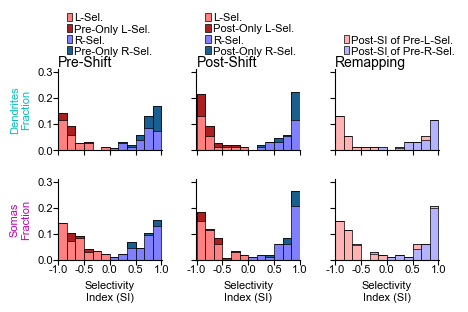

In [19]:
figName = 'Fig6_SI_alt2.pdf'
niceAnatLabels = ['Dendrites', 'Somas']
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
fontsize = 8
nBins = 12
linewidth = 0.5
nCols = 3
nRows = 2
hscalar = 1.5
vscalar = 1.25
CI = 68
ylims = [[0,0.31],[0,0.31],[0,0.31]]
xlim = [-1.01,1.01]
xticks = [-1,-0.5,0,0.5,1]
yticks = [0,0.1,0.2,0.3]
figSize = [nCols*hscalar,nRows*vscalar]
fig,axs=jsm.clean_subplots(nRows,nCols,figsize=figSize,constrained_layout =False, sharex=True, sharey=True)
plt.tight_layout()
bins = np.linspace(-1.0001,1.0001,nBins+1)
binCenters = 0.5*(bins[:-1]+bins[1:])
binWidths  = np.diff(bins)
for ak, anat in enumerate(anatKeys):  
    origSI = selectivityData[anat]['origSI']
    postSI = selectivityData[anat]['postSI']
    selEver = np.logical_or(np.isfinite(postSI),np.isfinite(origSI))
    selBoth = np.logical_and(np.isfinite(postSI),np.isfinite(origSI))
    for p in range(3):
        ax=axs[ak,p]
        if p==0:
            sScores=origSI
            sigOnlyThisPhase = np.logical_and(np.isfinite(sScores),np.isnan(postSI))
        else:
            sScores=postSI
            sigOnlyThisPhase = np.logical_and(np.isfinite(sScores),np.isnan(origSI))   
        if p == 0:
            label = 'Pre-Shift'
            label1 = 'Pre-Only'
        elif p == 1:
            label = 'Post-Shift'
            label1 = 'Post-Only'
        elif p == 2:
            label = 'Remapping'
            label1 = 'Post-Sel. of Pre-'
        if p!=2:
            for i in range(nBins):
                if i == nBins-1:
                    guysInBin = np.logical_and(sScores>=bins[i],sScores<=bins[i+1])
                else:
                    guysInBin = np.logical_and(sScores>=bins[i],sScores<bins[i+1])
        
                everyone = np.sum(guysInBin)/np.sum(selEver)
                onlySigNow = np.sum(guysInBin & sigOnlyThisPhase)/np.sum(selEver)
                offset = everyone - onlySigNow
                if binCenters[i] < 0:
                    eC = COLORS['L_light']
                    oC = COLORS['L_dark']
                else:
                    eC = COLORS['R_light']
                    oC = COLORS['R_dark']
                if i == 0 or i == nBins - 1:
                    if i == 0:
                        side = 'L'
                    elif i == nBins - 1:
                        side = 'R'
                    ax.bar(binCenters[i], everyone, width=binWidths[i], color=eC, alpha=1,edgecolor=(0,0,0),linewidth = linewidth,label = side+"-Sel.")
                    ax.bar(binCenters[i], onlySigNow, bottom=offset, width=binWidths[i], color=oC, alpha=1,edgecolor=(0,0,0),linewidth = linewidth,label = label1+" "+ side+"-Sel.")
                else:
                    ax.bar(binCenters[i], everyone, width=binWidths[i], color=eC, alpha=1,edgecolor=(0,0,0),linewidth = linewidth)
                    ax.bar(binCenters[i], onlySigNow, bottom=offset, width=binWidths[i], color=oC, alpha=1,edgecolor=(0,0,0),linewidth = linewidth)
            if p == 0:
                ax.set_ylabel(niceAnatLabels[ak] +'\nFraction',fontsize=fontsize,color=aColors[ak])
            if ak == 1:
                ax.set_xlabel('Selectivity\nIndex (SI)',fontsize=fontsize)
            ax.spines[['top','right']].set_visible(False)
            ax.set_ylim(ylims[p])
            ax.set_xlim(xlim)
            ax.set_xticks(xticks)
            ax.set_yticks(yticks)
            if ak == 0:
                ax.text(-1,ylims[p][1],label,fontsize=fontsize+2,ha='left',va='bottom',color=(0,0,0))
            ax.tick_params(axis='both', which='major', labelsize=fontsize, pad = 0) #

            if ak == 0:
                ax.legend(frameon=False,fontsize=fontsize,loc='lower left',bbox_to_anchor=(0, 1.05),\
                          handlelength=0.5, markerscale=0.5, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 

        else:
            wasL = np.logical_and(origSI<0, selBoth)
            wasR = np.logical_and(origSI>0, selBoth)

            switched_L_to_R = wasL & (postSI > 0)
            switched_R_to_L = wasR & (postSI < 0)
            switched = (switched_L_to_R)|(switched_R_to_L)
            print(anat, 'n =', f'{np.sum(switched):.03f}', f'{np.sum(switched)/len(switched):.03f}', 'totalN =', len(switched))
            
            sScores=copy.deepcopy(postSI)
            sScores[~selBoth]=np.NaN

            labeled = [0, 0]
            labeled1 = [0, 0]
            for i in range(nBins):
                if i == nBins-1:
                    guysInBin = np.logical_and(sScores>=bins[i],sScores<=bins[i+1])
                    side = 'R'
                    postIdx = 0
                else:
                    guysInBin = np.logical_and(sScores>=bins[i],sScores<bins[i+1])
                    side = 'L'
                    postIdx = 1
                everyone = np.sum(guysInBin)/np.sum(selEver)
                if binCenters[i] < 0:
                    weirdos = np.sum(guysInBin & wasR) / np.sum(selEver)
                    eC = COLORS['L_extralight']
                    wC = COLORS['R_extralight']
                    s1 = 'L'
                    s2 = 'R'
                    labeled[0]+=1
                    labeled1[postIdx]+=1
                else:
                    weirdos = np.sum(guysInBin & wasL) / np.sum(selEver)
                    eC = COLORS['R_extralight']
                    wC = COLORS['L_extralight']
                    s1 = 'R'
                    s2 = 'L'
                    labeled[1]+=1
                    labeled1[postIdx]+=1

                offset = everyone-weirdos
                if (labeled[0] == 1) or (labeled[1] == 1):
                    ax.bar(binCenters[i], everyone, width=binWidths[i], color=eC,alpha=1,edgecolor=(0,0,0),linewidth = linewidth,label = "Post-SI of Pre-"+s1+"-Sel.")
                    ax.bar(binCenters[i], weirdos, bottom = offset, width=binWidths[i], color=wC,alpha=1,edgecolor=(0,0,0),linewidth = linewidth)
                else:
                    ax.bar(binCenters[i], everyone, width=binWidths[i], color=eC,alpha=1,edgecolor=(0,0,0),linewidth = linewidth)
                    ax.bar(binCenters[i], weirdos, bottom = offset, width=binWidths[i], color=wC,alpha=1,edgecolor=(0,0,0),linewidth = linewidth)
            if p == 0:
                ax.set_ylabel(niceAnatLabels[ak] +'\nFraction',fontsize=fontsize,color=aColors[ak])
            if ak == 1:
                ax.set_xlabel('Selectivity\nIndex (SI)',fontsize=fontsize)
            ax.spines[['top','right']].set_visible(False)
            ax.set_ylim(ylims[p])
            ax.set_xlim(xlim)
            ax.set_xticks(xticks)
            ax.set_yticks(yticks)
            if ak == 0:
                ax.text(-1,ylims[p][1],label,fontsize=fontsize+2,ha='left',va='bottom',color=(0,0,0))
            ax.tick_params(axis='both', which='major', labelsize=fontsize, pad = 0) #
            if ak == 0:
                ax.legend(frameon=False,fontsize=fontsize,loc='lower left',bbox_to_anchor=(0, 1.05),\
                          handlelength=0.5, markerscale=0.5, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 

with maybe_pdf(os.path.join(FIG_EXPORT_DIR,figName)) as pdf:
    pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
jsm.display_clean_subplots(fig,axs)


In [20]:
allSig = {}
allSI = {}
allDenom = {}
allNum = {}
nBoot = 10000
for ak, anat in enumerate(anatKeys):  
    SI = np.vstack([selectivityData[anat]['origSI'],selectivityData[anat]['postSI']])
    denom = np.vstack([selectivityData[anat]['origDenom'],selectivityData[anat]['postDenom']])
    num = np.vstack([selectivityData[anat]['origNum'],selectivityData[anat]['postNum']])
    masks = np.isfinite(SI)
    aSI = np.zeros([2,nBoot])
    aDenom = np.zeros([2,nBoot])
    aNum = np.zeros([2,nBoot])
    aNsig = np.zeros([2,nBoot])
    nAnms = len(np.unique(allAnmIdxs[anat]))
    for i in range(nBoot):
        bN=0
        maskIdx=[]
        for k in range(10000):
            if bN>=len(allAnmIdxs[anat]):
                break
            anm = np.random.choice(nAnms, 1)
            idx = (allAnmIdxs[anat]==anm).nonzero()[0]
            bN=bN+len(idx)
            maskIdx.append(idx)    
        maskIdx = np.hstack(maskIdx)[:len(allAnmIdxs[anat])]
        masksB = np.vstack([masks[:,x] for x in maskIdx]).T
        SIB = np.vstack([SI[:,x] for x in maskIdx]).T
        denomB = np.vstack([denom[:,x] for x in maskIdx]).T
        numB = np.vstack([num[:,x] for x in maskIdx]).T
        for p in range(2):
            finalMask = masksB[p,:]==1
            aSI[p,i] = np.nanmean(np.abs(SIB[p,:][finalMask]))
            aDenom[p,i] = np.nanmean(np.abs(denomB[p,:][finalMask]))
            aNum[p,i] = np.nanmean(np.abs(numB[p,:][finalMask]))
            aNsig[p,i] = np.nansum(finalMask)
    allSig[anat] = aNsig
    allSI[anat] = aSI
    allDenom[anat] = aDenom
    allNum[anat] = aNum
    
data = [allSig,allSI,allDenom,allNum] 
data2Plot=[]
for x in data:
    data2Plot.append([(x[anat][1]/x[anat][0]-1)*100 for anat in anatKeys])

# Sel. Masks mean: 5.903 std: 6.003 pval: 0.278400
# Sel. Masks mean: 7.514 std: 5.902 pval: 0.175600
anat p = 0.4156
Sel. Index [R-L]/[R+L] mean: 3.890 std: 2.613 pval: 0.156600
Sel. Index [R-L]/[R+L] mean: 10.850 std: 3.794 pval: 0.002800
anat p = 0.0643
Response [R+L] mean: -13.691 std: 4.821 pval: 0.012200
Response [R+L] mean: 11.443 std: 4.093 pval: 0.008600
anat p = 0.0002
Sel. Mag. [R-L] mean: -5.755 std: 5.219 pval: 0.266000
Sel. Mag. [R-L] mean: 26.234 std: 5.402 pval: 0.000000
anat p = 0.0


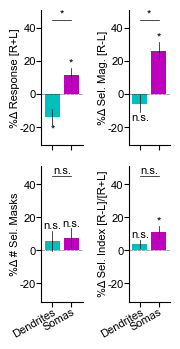

In [21]:
figName = 'Fig6_SI_perChange.pdf'
fontsize = 8
niceAnatLabels = ['Dendrites','Somas']
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "boot. median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "boot. mean±SEM"
elif error == 'std':
    errorLabel = "boot. mean±SD"
linewidth = 0.5
figsize = [1.9,3.6]
alphas = [0.5,.8]
akLine = 45
ylim = [-31,51]
fig,axs=jsm.clean_subplots(2,2,figsize=figsize,facecolor='none',constrained_layout = False, sharex = True)

ylabels = [f'# Sel. Masks',
           f'Sel. Index [R-L]/[R+L]',
           f'Response [R+L]',
           f'Sel. Mag. [R-L]']
testLS = ':'
testDashes = (5,1)
testLW = linewidth
testColor = (0,0,0)
testAlpha = 0.5
testLine = 0
row = -1
col = -1
for i, data in enumerate(data2Plot):
    col+=1
    if col == 2:
        col = 0
        row+=1
    ax = axs[row,col]
    ax.axhline(testLine, lw = testLW, color = testColor, linestyle = testLS, alpha = testAlpha,dashes=testDashes)

    for ak, anat in enumerate(anatKeys):

        mean = np.nanmean(data[ak],axis=0)
        med = np.nanmedian(data[ak],axis=0)
        std = np.nanstd(data[ak],axis=0, ddof = 1)
        sem = std / np.sqrt(data[ak].shape[0])
        low,high = np.nanpercentile(data[ak], [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
        if error == 'CI':
            mainPlot = med
            errorLow = low
            errorHigh = high
        elif error == 'sem':
            mainPlot = mean
            errorLow = mean-sem
            errorHigh = mean+sem
        elif error == 'std':
            mainPlot = mean
            errorLow = mean-std
            errorHigh = mean+std
        x = ak/4

        ax.bar(x,mainPlot, color = aColors[ak], width = 0.2, alpha = 1)
        ax.plot([x,x],[errorLow,errorHigh],color = (0,0,0),lw=linewidth)
    
        tail1 = np.sum(data[ak]<testLine)/np.sum(np.isfinite(data[ak]))
        tail2 = np.sum(data[ak]>testLine)/np.sum(np.isfinite(data[ak]))
        twoTails = 2 * min(tail1, tail2)
        pVal = min(twoTails, 1.0)
        pText = jsm.pstar(pVal,inclP = False)

        print(ylabels[i], f'mean: {mainPlot:.03f}', f'std: {std:.03f}', f'pval: {pVal:03f}')

        if mainPlot<testLine:
            text_ypos = errorLow
            va='top'
        else:
            text_ypos = errorHigh
            va = 'bottom'

        ax.text(x,text_ypos,pText,fontsize=fontsize,ha='center',va=va)
    
    pVal = np.sum(data[0]>data[1])/nBoot
    pText = jsm.pstar(pVal,inclP = False)
    print('anat p = '+str(pVal))
    ax.set_ylim(ylim)
    ax.plot([0,0.25],[akLine,akLine], lw = linewidth, color = (0,0,0))
    ax.text(.125,akLine,pText,fontsize=fontsize,ha='center',va='bottom')

    ax.spines[['top','right']].set_visible(False)
    ax.set_ylabel("%Δ "+ ylabels[i],fontsize=fontsize,labelpad=0)
    ax.set_xlim([-0.15,0.4])
    ax.set_xticks([0,0.25])
    ax.set_xticklabels(niceAnatLabels,fontsize=fontsize-2,rotation=30,ha='right',va='top',rotation_mode='anchor')

    ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 0) #
    ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 0) #

with maybe_pdf(os.path.join(FIG_EXPORT_DIR,figName)) as pdf:
    pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
jsm.display_clean_subplots(fig,axs)


# pre post Projections
## note the smaller bins now

In [22]:
dffKey = 'impulse_trace'##'consensus_NMFtc_dff_bc_decon_sp'#'consensus_NMFtc_dff_bc'
dffKeys = ['impulse_trace']#['consensus_NMFtc_dff_bc_decon_sp', 'consensus_NMFtc_dff_bc', 'impulse_trace']
maskKey = 'trace_mask'

factors = [10,5]
Z = 'std_only'
phases2 = ['pre', 'preShift_early', 'preShift_late', 'post', 'late', 'day-1_beg', 'day-1_mid', 'day-1_end', 'shiftDay_post', 'shiftDay_pre', 'early'] 
windowSize = [-3.6,3.6]

allAnmParams = jsm.get_allAnmParams(masterData, anms, frs, factors, Z, phases2, dffKeys, maskKey=maskKey, windowSize = windowSize)


0 B00002121749
Getting params for somas impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
relDays: [-8 -2  0  2  5]
phase: preShift_late, days used: [-2  0]
phase: early, days used: [0, 2]
1 B00002121774
Getting params for dendrites impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
Getting params for somas impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
<<WARNING>> [tsep_traces()] B00002121774 07-Oct-2022 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002121774 sess0 07-Oct-2022 len(trial_frames) = 305 len(tsep_sess) = 306
<<WARNING>> [tsep_traces()] B00002121774 09-Oct-2022 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002121774 sess1 09-Oct-2022 len(trial_frames) = 284 len(tsep_sess) = 285
relDays: [-6 -5 

/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/functions/js_manuscript_final.py:2555: RuntimeWarning: All-NaN slice encountered
  closestDist.append(np.nanmin(tDist))


2 B00002121777
Getting params for dendrites impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
<<WARNING>> [tsep_traces()] B00002121777 221008 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002121777 sess1 221008 len(trial_frames) = 374 len(tsep_sess) = 375
Getting params for somas impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
<<WARNING>> [tsep_traces()] B00002121777 221009 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002121777 sess1 221009 len(trial_frames) = 293 len(tsep_sess) = 294
<<WARNING>> [tsep_traces()] B00002121777 221013 IGNORING SESSION
            KNOWN ISSUE ignore_session 294
            KNOWN ISSUE description imaging issues
<<WARNING>> [get_tsep_wFlag()] B00002121777 sess2 221013 len(trial_frames) = 127

/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/functions/js_manuscript_final.py:2555: RuntimeWarning: All-NaN slice encountered
  closestDist.append(np.nanmin(tDist))


6 B00002213785
Getting params for dendrites impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
<<WARNING>> [tsep_traces()] B00002213785 230131 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002213785 sess2 230131 len(trial_frames) = 212 len(tsep_sess) = 213
Getting params for somas impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
<<WARNING>> [tsep_traces()] B00002213785 230203 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002213785 sess3 230203 len(trial_frames) = 253 len(tsep_sess) = 254
relDays: [-5 -4 -2 -1  0  1  2  3  4]
phase: preShift_early, days used: [-4 -2]
phase: preShift_late, days used: [-1  0]
phase: late, days used: [2 3]
phase: early, days used: [0, 1]


/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/functions/js_manuscript_final.py:2555: RuntimeWarning: All-NaN slice encountered
  closestDist.append(np.nanmin(tDist))


7 B00002213889
Getting params for dendrites impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
Getting params for somas impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
relDays: [-4 -3 -2 -1  0  1  2]
phase: preShift_early, days used: [-3 -2]
phase: preShift_late, days used: [-1  0]
phase: early, days used: [0, 1]
8 B00002213908
Getting params for dendrites impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
Getting params for somas impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
relDays: [-4 -3 -2 -1  0  1  2  4  5]
phase: preShift_early, days used: [-3 -2]
phase: preShift_late, days used: [-1  0]
phase: late, days used: [2 4]
phase: early, days used: [0, 1]
9 B00002213909
Getting params for dendrites impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
Getting params for somas impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
relDays: [-7 -6 -4 -3 -2]
phase: preShift_early, days used: [-6 -4]
phase: preS

/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/functions/js_manuscript_final.py:2555: RuntimeWarning: All-NaN slice encountered
  closestDist.append(np.nanmin(tDist))


### preCalc

In [23]:

thrsh = 0.05
minTrials = 10
anatKeys = ['dendrites', 'somas']

aAnms, keepRoisFull, keepRoisDS, allNaNs = jsm.check_anms_ROIs(allAnmParams, anms, anatKeys, dffKey, thrsh)
aAnms, iAnms, anmsMinTrial, allMinTrials = jsm.check_trials(allAnmParams, anms, anatKeys, dffKey, minTrials)

full
dendrites 327 / 402 0.813
somas 479 / 528 0.907

dendrites B00002121774 334 264 74 15
dendrites B00002213772 350 361 34 72
dendrites B00002213773 190 196 32 67
dendrites B00002213784 308 260 20 23
dendrites B00002213785 271 264 43 68
dendrites B00002213908 266 242 43 41
dendrites B00002213909 337 306 142 47
dendrites B00002213921 254 301 51 47
dendrites B00002213943 311 340 24 50
dendrites B00002213998 366 28 148 17
somas B00002121749 164 41 45 15
somas B00002121774 238 229 58 35
somas B00002213772 258 288 25 74
somas B00002213773 107 80 18 19
somas B00002213785 235 250 25 49
somas B00002213889 321 229 59 22
somas B00002213908 270 227 103 73
somas B00002213909 251 198 142 18
somas B00002213921 281 290 23 20
somas B00002213943 286 275 29 20
somas B00002213997 187 83 256 18
somas B00002213999 287 207 15 12
12
Finished processing trials.


In [24]:

iAnms = {}
aAnms = {}
minTrials = 100
anmsMinTrial = {}
for anat in anatKeys:
    iAnms[anat] = []
    aAnms[anat] = []
    anmsMinTrial[anat] = {}
    for anm in anms:
        if anat in list(allAnmParams[anm][dffKey]['dsTsep'].keys()):
            aAnms[anat].append(anm)
            tracker = allAnmParams[anm]['tracker']
            dendDays = allAnmParams[anm]['dendDays']
            preMask = allAnmParams[anm]['shiftMask']['pre']
            postMask = allAnmParams[anm]['shiftMask']['post']
            earlyMask = allAnmParams[anm]['shiftMask']['early']
            lateMask = allAnmParams[anm]['shiftMask']['late']
            me = allAnmParams[anm]['me']
            de = allAnmParams[anm]['de']

            if anat == 'dendrites':
                anatMask = dendDays
            else:
                anatMask = ~dendDays

            preAnatMask = np.logical_and(anatMask, preMask)
            postAnatMask = np.logical_and(anatMask, postMask)
            pretkr = tracker[preAnatMask,:]
            posttkr = tracker[postAnatMask,:]
            pCR = np.sum(posttkr[:,2]==0)
            pCL = np.sum(posttkr[:,2]==1)
            preCR = np.sum(pretkr[:,2]==0)
            preCL = np.sum(pretkr[:,2]==1)
            ftsep = allAnmParams[anm][dffKey]['fullTsep'][anat]['full']
            dsTsep = allAnmParams[anm][dffKey]['dsTsep'][anat]['full']

            if np.all(np.hstack([item>minTrials for item in [pCR, pCL, preCR, preCL]])):
                if anm != 'B00002121777':
                    if ftsep.shape[1]>=10:
                        iAnms[anat].append(anm)
                        print(anat, anm, np.sum(pCR),np.sum(pCL))
                        anmsMinTrial[anat][anm] = np.min(np.hstack([pCR, pCL, preCR, preCL]))
print(iAnms)

dendrites B00002121774 295 244
dendrites B00002213772 311 199
dendrites B00002213784 377 254
dendrites B00002213785 166 141
dendrites B00002213908 178 138
dendrites B00002213920 245 226
dendrites B00002213932 253 210
dendrites B00002213970 130 294
dendrites B00002213982 170 175
dendrites B00002213985 248 250
dendrites B00002213997 228 177
dendrites B00002213999 365 268
somas B00002121774 237 224
somas B00002213772 432 223
somas B00002213784 243 180
somas B00002213785 166 140
somas B00002213889 226 139
somas B00002213908 336 222
somas B00002213920 229 199
somas B00002213982 225 200
somas B00002213999 276 190
somas B00002214001 161 199
{'dendrites': ['B00002121774', 'B00002213772', 'B00002213784', 'B00002213785', 'B00002213908', 'B00002213920', 'B00002213932', 'B00002213970', 'B00002213982', 'B00002213985', 'B00002213997', 'B00002213999'], 'somas': ['B00002121774', 'B00002213772', 'B00002213784', 'B00002213785', 'B00002213889', 'B00002213908', 'B00002213920', 'B00002213982', 'B0000221399

In [25]:
iAnms2 = {}
aAnms2 = {}
minTrials = 10
for anat in anatKeys:
    iAnms2[anat] = []
    aAnms2[anat] = []
    for anm in anms:
        if anat in list(allAnmParams[anm][dffKey]['dsTsep'].keys()):
            aAnms2[anat].append(anm)
            tracker = allAnmParams[anm]['tracker']
            dendDays = allAnmParams[anm]['dendDays']
            cTimes = allAnmParams[anm]['cTimes']
            goCues = allAnmParams[anm]['goCues']
            preMask = allAnmParams[anm]['shiftMask']['pre']
            postMask = allAnmParams[anm]['shiftMask']['post']
            earlyMask = allAnmParams[anm]['shiftMask']['early']
            lateMask = allAnmParams[anm]['shiftMask']['late']
            me = allAnmParams[anm]['me']
            de = allAnmParams[anm]['de']
            ar = allAnmParams[anm]['afterRight']
            al = allAnmParams[anm]['afterLeft']
            an = allAnmParams[anm]['afterNone']
            ln = np.logical_or(al, an)

            if anat == 'dendrites':
                anatMask = dendDays
            else:
                anatMask = ~dendDays

            preAnatMask = np.logical_and(anatMask, preMask)
            postAnatMask = np.logical_and(anatMask, postMask)
            pretkr = tracker[preAnatMask,:]
            posttkr = tracker[postAnatMask,:]
            postME = me[postAnatMask]
            postDE = de[postAnatMask]
            postAR = ar[postAnatMask]
            postAL = al[postAnatMask]
            postAN = an[postAnatMask]
            postLN = ln[postAnatMask]
            
            pCR = np.sum(posttkr[:,2]==0)
            pCL = np.sum(posttkr[:,2]==1)
            pMER = np.sum(np.logical_and(postME, posttkr[:,2]==5))
            pDER = np.sum(np.logical_and(postDE, posttkr[:,2]==5))
            pAR = np.sum(postAR)
            pAL = np.sum(postAL)
            pAN = np.sum(postAN)
            pNL = np.sum(postLN)
            
            ftsep = allAnmParams[anm][dffKey]['fullTsep'][anat]['full']
            dsTsep = allAnmParams[anm][dffKey]['dsTsep'][anat]['full']

            if pAR>minTrials and pCR>minTrials:# and pAL>minTrials:# and anmLearn[anm]==(1,0,0):
                if anm != 'B00002121777':
                    if ftsep.shape[1]>=10:
                        iAnms2[anat].append(anm)
                        print(anat, anm, np.sum(pAR), np.sum(pAL), np.sum(pCR))
print(iAnms2)

dendrites B00002121774 93 4 295
dendrites B00002213772 31 17 311
dendrites B00002213784 26 5 377
dendrites B00002213785 44 17 166
dendrites B00002213908 36 42 178
dendrites B00002213932 66 19 253
dendrites B00002213970 269 195 130
dendrites B00002213982 176 98 170
dendrites B00002213997 295 35 228
dendrites B00002213998 202 50 233
dendrites B00002213999 86 54 365
somas B00002121749 25 25 113
somas B00002121774 160 17 237
somas B00002213772 29 35 432
somas B00002213784 28 8 243
somas B00002213889 16 7 226
somas B00002213908 53 21 336
somas B00002213982 108 5 225
somas B00002213985 29 4 143
somas B00002213997 124 14 169
somas B00002213999 47 64 276
somas B00002214001 78 32 161
{'dendrites': ['B00002121774', 'B00002213772', 'B00002213784', 'B00002213785', 'B00002213908', 'B00002213932', 'B00002213970', 'B00002213982', 'B00002213997', 'B00002213998', 'B00002213999'], 'somas': ['B00002121749', 'B00002121774', 'B00002213772', 'B00002213784', 'B00002213889', 'B00002213908', 'B00002213982', 'B

In [26]:
for ak, anat in enumerate(anatKeys):
    anms1 = iAnms[anat]
    anms2 = iAnms2[anat]
    print(anat, f'MER {len(anms1)}', f'Motor {len(anms2)}', f'Both {np.sum(np.isin(anms1, anms2))}')
bothAnms = {}
for ak, anat in enumerate(anatKeys):
    anms1 = iAnms[anat]
    anms2 = iAnms2[anat]
    print(anat, f'MER {len(anms1)}', f'Motor {len(anms2)}', f'Both {np.sum(np.isin(anms1, anms2))}')
    bothAnms[anat] = np.hstack(anms1)[np.isin(anms1, anms2)]
bothAnms

dendrites MER 12 Motor 11 Both 10
somas MER 10 Motor 11 Both 8
dendrites MER 12 Motor 11 Both 10
somas MER 10 Motor 11 Both 8


{'dendrites': array(['B00002121774', 'B00002213772', 'B00002213784', 'B00002213785',
        'B00002213908', 'B00002213932', 'B00002213970', 'B00002213982',
        'B00002213997', 'B00002213999'], dtype='<U12'),
 'somas': array(['B00002121774', 'B00002213772', 'B00002213784', 'B00002213889',
        'B00002213908', 'B00002213982', 'B00002213999', 'B00002214001'],
       dtype='<U12')}

In [27]:
psWindow = [-3.6,3.6]
useDS = True
anmsToUse = bothAnms
shuffAnms = True
shuffRois = False
enforceMinTrial = True
binary = False

allAnms = np.unique(np.hstack([anmsToUse[anat] for anat in anatKeys]))
phases = ['pre', 'post']
pLabels = ['pre', 'post']
mods = ['GO','CT']#,'errGO', 'errCT']
alignTimes = ['goCues','cTimes']#,'goCues','cTimes']

nBoot = 10000
megaTseps = {}
megaTsepsHH = {}
emptyMegaTsep = {'dendrites': [], 'somas': []}

for p, phase in enumerate(phases):
    megaTseps[phase] = {}
    megaTsepsHH[f'{phase}1'] = {}
    megaTsepsHH[f'{phase}2'] = {}
    for mod in mods:
        megaTseps[phase][mod] = copy.deepcopy(emptyMegaTsep)
        megaTsepsHH[f'{phase}1'][mod] = copy.deepcopy(emptyMegaTsep)
        megaTsepsHH[f'{phase}2'][mod] = copy.deepcopy(emptyMegaTsep)

#making holder matracies
somaTime = allAnmParams[anmsToUse['somas'][0]][dffKey]['dsTsep']['somas']['go-psTsep'].shape[2]
nSoma = 0
for anm in anmsToUse['somas']:
    nSoma+=allAnmParams[anm][dffKey]['dsTsep']['somas']['go-psTsep'][:,keepRoisDS['somas'][anm],:].shape[1]
    
dendTime = allAnmParams[anmsToUse['dendrites'][0]][dffKey]['dsTsep']['dendrites']['go-psTsep'].shape[2]
nDend = 0
for anm in anmsToUse['dendrites']:
    nDend+=allAnmParams[anm][dffKey]['dsTsep']['dendrites']['go-psTsep'][:,keepRoisDS['dendrites'][anm],:].shape[1]

somaEmpty = np.empty([4, somaTime, nSoma, nBoot])
dendEmpty = np.empty([4, dendTime, nDend, nBoot])
empties = [dendEmpty, somaEmpty]
for phase in phases:
    for mod in mods:
        for ak, anat in enumerate(anatKeys):
            megaTseps[phase][mod][anat] = copy.deepcopy(empties[ak])
            megaTsepsHH[f'{phase}1'][mod][anat] = copy.deepcopy(empties[ak])
            megaTsepsHH[f'{phase}2'][mod][anat] = copy.deepcopy(empties[ak])    
for i in tqdm(range(nBoot)):
    for ak, anat in enumerate(anatKeys):
        if shuffAnms:
            anmIdxs = np.random.choice(np.arange(len(anmsToUse[anat])), len(anmsToUse[anat]))
        else:
            anmIdxs = np.arange(len(anmsToUse[anat]))
        nRois = np.sum(np.hstack([np.sum(keepRoisDS[anat][anm]) for anm in anmsToUse[anat]]))
        for m, mod in enumerate(mods):
            if 'err' in mod:
                returnErrors = True
            else:
                returnErrors = False
            
            mT = jsm.gather_anmShuff_megaTsepFull(allAnmParams, anat, ak, mod, phases, frs, keepRoisDS, dffKey, alignTimes[m], anmsToUse, nRois,
                                                  anmIdxs, enforceMinTrial, binary, returnErrors, anmsMinTrial)
            
            mT1, mT2 = jsm.gather_anmShuff_megaTsepHH(allAnmParams, anat, ak, mod, phases, frs,  keepRoisDS, dffKey, alignTimes[m], anmsToUse, nRois,
                                                  anmIdxs, enforceMinTrial, binary, returnErrors, anmsMinTrial)
            for phase in phases:
                megaTseps[phase][mod][anat][:,:,:,i] = mT[phase]
                megaTsepsHH[f'{phase}1'][mod][anat][:,:,:,i] = mT1[phase]
                megaTsepsHH[f'{phase}2'][mod][anat][:,:,:,i] = mT2[phase]

  0%|          | 0/10000 [00:00<?, ?it/s]

In [28]:
for ak, anat in enumerate(anatKeys):
    print(anat, megaTsepsHH[f'{phases[0]}2'][mod][anat].shape)
for anat in anatKeys:
    print(anat, len(bothAnms[anat]))

dendrites (4, 32, 167, 10000)
somas (4, 34, 179, 10000)
dendrites 10
somas 8


In [29]:
nBoot = 10000

allAnmCDs = {}
allAnmDenoms = {}
allAnmIdxs = {}
takeEqualTrials = True
anmsToUse = bothAnms
for ak, anat in enumerate(anatKeys):
    allAnmCDs[anat] = {}
    allAnmDenoms[anat] = {}
    allAnmIdxs[anat] = []
    F = frs[ak]/factors[ak]
    for a, anm in enumerate(anmsToUse[anat]):
        print(anm+" "+anat)
        nROI = np.sum(keepRoisDS[anat][anm])
        allAnmIdxs[anat].append(np.ones(nROI)*a)
        allAnmCDs[anat][anm] = {}
        allAnmDenoms[anat][anm] = {}
        nTriToGrab=[]
        for phase in ['pre','post']:
    
            anmData = allAnmParams[anm]
            tsep = anmData[dffKey]['dsTsep'][anat]['go-psTsep']
            sMask = anmData['shiftMask'][phase]
            dd = anmData['dendDays']
            if anat == 'dendrites':
                anatMask = dd
            else:
                anatMask = ~dd
            tracker = anmData['tracker']
            fullMask = np.logical_and(anatMask, sMask)
            roiMask = keepRoisDS[anat][anm]
            
            pTkr = tracker[fullMask,:]
            crM = pTkr[:,2]==0
            crT = np.where(crM)[0]

            clM = pTkr[:,2]==1
            clT = np.where(clM)[0]
            
            pTsep = tsep[fullMask[anatMask],:,:]
            pTsep = pTsep[:,roiMask,:]

            nTriToGrab.append(np.min([np.sum(clM), np.sum(crM)]))
        nTriToGrab=np.min(nTriToGrab)
        
        for phase in ['pre','post']:
    
            anmData = allAnmParams[anm]
            tsep = anmData[dffKey]['dsTsep'][anat]['go-psTsep']
            sMask = anmData['shiftMask'][phase]
            dd = anmData['dendDays']
            if anat == 'dendrites':
                anatMask = dd
            else:
                anatMask = ~dd
            tracker = anmData['tracker']
            fullMask = np.logical_and(anatMask, sMask)
            roiMask = keepRoisDS[anat][anm]
            
            pTkr = tracker[fullMask,:]
            crM = pTkr[:,2]==0
            crT = np.where(crM)[0]

            clM = pTkr[:,2]==1
            clT = np.where(clM)[0]
            
            pTsep = tsep[fullMask[anatMask],:,:]
            pTsep = pTsep[:,roiMask,:]            
            CDs = []
            denoms = []
            for i in tqdm(range(nBoot)):
                if takeEqualTrials:
                    bCRm = np.random.choice(crT, nTriToGrab)
                    bCLm = np.random.choice(clT, nTriToGrab)
                else:
                    bCLm = np.random.choice(clT, len(clT))
                    bCRm = np.random.choice(crT, len(crT))
                CR = np.nanmean(pTsep[bCRm,:,:], axis = 0)
                CL = np.nanmean(pTsep[bCLm,:,:], axis = 0)
                denom = np.abs((np.nanmean(pTsep[bCRm,:,:],axis = 0))+np.abs(np.nanmean(pTsep[bCLm,:,:],axis = 0)))
                cd = (CR-CL)/denom
                CDs.append(cd)
                denoms.append(denom)
            CDs = np.stack(CDs)
            denoms = np.stack(denoms)#boot x roi x time
            allAnmCDs[anat][anm][phase] = CDs
            allAnmDenoms[anat][anm][phase] = denoms
    allAnmIdxs[anat] = np.hstack(allAnmIdxs[anat])

B00002121774 dendrites


  0%|          | 0/10000 [00:00<?, ?it/s]

/tmp/ipykernel_1194786/3451015518.py:82: RuntimeWarning: invalid value encountered in divide
  cd = (CR-CL)/denom


  0%|          | 0/10000 [00:00<?, ?it/s]

B00002213772 dendrites


...

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

B00002214001 somas


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

## CRCL HH Scroll

In [30]:
%%time

nBoots = 10000
CRCL_HHscroll = {}
for ak, anat in enumerate(anatKeys):
    CRCL_HHscroll[anat] = {}
    for calcPhase in ['pre1','pre2','post1', 'post2']:
        CRCL_HHscroll[anat][calcPhase] = {}
        for m, mod in enumerate(['CT','GO']):#,'LL']):
            print('starting', anat, calcPhase, mod)
            allData = jsm.get_CRCL_CD_fast(megaTsepsHH,anat, mod, calcPhase, nBoots)
            CRCL_HHscroll[anat][calcPhase][mod] = allData
print('done')

starting dendrites pre1 CT
starting dendrites pre1 GO
starting dendrites pre2 CT
starting dendrites pre2 GO
starting dendrites post1 CT
starting dendrites post1 GO
starting dendrites post2 CT
starting dendrites post2 GO
starting somas pre1 CT
starting somas pre1 GO
starting somas pre2 CT
starting somas pre2 GO
starting somas post1 CT
starting somas post1 GO
starting somas post2 CT
starting somas post2 GO
done
CPU times: user 53.6 s, sys: 1.61 s, total: 55.2 s
Wall time: 55.5 s


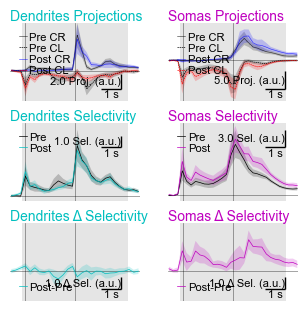

In [31]:
figName = 'Fig6_projections.pdf'
figSize = [3,3]
nRows= 3
nCols = 2
fig, axs = jsm.clean_subplots(nRows,nCols,figSize, sharex = True, constrained_layout = True)
fontsize = 8
labels = ['Pre','Post','Post-Pre']# 'postPost']
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
colors = [(0,0,0),(0,1,0),'']
preColor = (0,0,0)
preColors = [(0,0,0),(0,0,0)]
postColors = [(0,0,1),(1,0,0)]
preLS = [':','--']
postLS = ['-','-']
preDashes = [(1, 0.5), (2, 1)]
postDashes = [(1, 0.5), (2, 1)]
trialLabels = ['CR', 'CL','MER','DER']
niceAnatLabels = ['Dendrites', 'Somas']
offsets = [5,10]
allDifs = {}
allSels = {}
xlim = [-3.2,3.2]
xticks = np.arange(7)-3
ylims1 = [[-4,6.2],[-11,10]]
ylims2 = [[-0.5,7],[-1,13]]
ylims3 = [[-2.5,4],[-2.5,4]]
window = [3.6,3.6+2.6]
plotLims = [-3.6,3.6]
linewidth = 0.5
mod = 'GO'
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap\nmedian±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "boot. mean±SEM"
elif error == 'std':
    errorLabel = "boot. mean±SD"
if mod == 'GO':
    alignTime = 'Go Cue'
    markers = [0,-1.25,-2.45]
    markers = [0,-2.45]
else:
    alignTime = 'Contact'
    markers = [0]

plot_scaleBar={}
plot_scaleBar['corner']='BR'
plot_scaleBar['length_s'] = 1
plot_scaleBar['height_per'] = 0.25
plot_scaleBar['lw'] = 1
plot_scaleBar['horzAdjust']=0.1
plot_scaleBar['fontsize'] = fontsize
plot_scaleBar['includeLabel'] = True

markerLS = '-'
markerLW = 0.5
markerColor = (0,0,0)
markerAlpha = 0.5

for ak, anat in enumerate(anatKeys):
    #ax = axs[ak]
    pre = CRCL_HHscroll[anat]['pre1'][mod]['projs']['pre2'] #boot, time, trial
    preSel = pre[:,0,:]-pre[:,1,:]
    
    post = CRCL_HHscroll[anat]['post1'][mod]['projs']['post2']
    postSel = post[:,0,:]-post[:,1,:]

    allSels[anat] = {}
    allSels[anat]['pre'] = preSel
    allSels[anat]['post'] = postSel

    dif = postSel - preSel

    allDifs[anat] = dif

    ax = axs[1,ak]
    sels = [preSel,postSel]
    traces = [pre,post,dif]

    titles2 = ['Projections', 'Selectivity','Δ Selectivity']
    titles3 = ['Proj.', 'Sel.','Δ Sel.']
    for a, ax in enumerate(axs[:,ak]):
        if a == 0:
            ax.set_ylim(ylims1[ak])
            plot_scaleBar['vertAdjust']=0.15
        elif a == 1:
            ax.set_ylim(ylims2[ak])
            plot_scaleBar['vertAdjust']=0.7
        elif a == 2:
            ax.set_ylim(ylims3[ak])
            plot_scaleBar['vertAdjust']=0.15

        ylim = ax.get_ylim()
        ax.text(xlim[0],ylim[1],niceAnatLabels[ak]+" "+titles2[a],color=aColors[ak],fontsize=fontsize+2,ha='left',va='bottom')

        for mark in markers:
            ax.plot([mark]*2,ylim,lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
        ax.axhline(0, lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)

        ax.fill_between(np.hstack([-2.6, 2.6]), ylim[0], ylim[1], color = (0,0,0), alpha = 0.1, edgecolor='none')

        vertLabel = titles3[a]+' (a.u.)\n('+errorLabel+')'
        vertLabel = titles3[a]+' (a.u.)'

        ax,plot_scaleBar = jsm.add_plot_scaleBar(ax,plot_scaleBar,(0,0,0),True,vertLabel)

    for p in [0,1]:
        row = 0
        ax = axs[row,ak]
        for t in range(2):
            data = traces[p][:,t,:]
            if p == 0:
                color = (0,0,0)
            else:
                color = postColors[t]
            mean = np.nanmean(data,axis=0)
            med = np.nanmedian(data,axis=0)
            std = np.nanstd(data,axis=0, ddof = 1)
            sem = std / np.sqrt(data.shape[0])
            low,high = np.nanpercentile(data, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
            x = np.linspace(plotLims[0],plotLims[1],len(mean))
            plotIdx = np.arange(np.argmin(np.absolute(x-xlim[0])),np.argmin(np.absolute(x-xlim[1]))+1)
            if error == 'CI':
                mainPlot = med
                errorLow = low
                errorHigh = high
            elif error == 'sem':
                mainPlot = mean
                errorLow = mean-sem
                errorHigh = mean+sem
            elif error == 'std':
                mainPlot = mean
                errorLow = mean-std
                errorHigh = mean+std
            if p == 1:
                ax.fill_between(x[plotIdx], errorLow[plotIdx], errorHigh[plotIdx], color = postColors[t], alpha = 0.2, edgecolor='none')
                ax.plot(x[plotIdx], mainPlot[plotIdx], ls = postLS[t], color = postColors[t], label = "Post "+trialLabels[t],lw=linewidth,dashes=postDashes[t])
            else:
                ax.fill_between(x[plotIdx], errorLow[plotIdx], errorHigh[plotIdx], color = preColors[t], alpha = 0.2, edgecolor='none')
                ax.plot(x[plotIdx], mainPlot[plotIdx], ls = preLS[t], color = preColors[t], label =  "Pre "+trialLabels[t],lw=linewidth,dashes=preDashes[t])
        ax.set_xlim(xlim)
        ax.set_ylim(ylims1[ak])
        ax.legend(frameon=False,fontsize=fontsize,loc='upper left',\
                   handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 

        row = 1
        ax = axs[row,ak]
        data = sels[p]
        lss = ['-','-']
        mean = np.nanmean(data,axis=0)
        med = np.nanmedian(data,axis=0)
        std = np.nanstd(data,axis=0, ddof = 1)
        sem = std / np.sqrt(data.shape[0])
        low,high = np.nanpercentile(data, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
        x = np.linspace(plotLims[0],plotLims[1],len(mean))
        plotIdx = np.arange(np.argmin(np.absolute(x-xlim[0])),np.argmin(np.absolute(x-xlim[1]))+1)
        if error == 'CI':
            mainPlot = med
            errorLow = low
            errorHigh = high
        elif error == 'sem':
            mainPlot = mean
            errorLow = mean-sem
            errorHigh = mean+sem
        elif error == 'std':
            mainPlot = mean
            errorLow = mean-std
            errorHigh = mean+std
        if p == 1:
            ax.fill_between(x[plotIdx], errorLow[plotIdx], errorHigh[plotIdx], color = aColors[ak], alpha = 0.2, edgecolor='none')
            ax.plot(x[plotIdx], mainPlot[plotIdx], ls = lss[p], color = aColors[ak], label = labels[p],lw=linewidth)
        else:
            ax.fill_between(x[plotIdx], errorLow[plotIdx], errorHigh[plotIdx], color = preColor, alpha = 0.2, edgecolor='none')
            ax.plot(x[plotIdx], mainPlot[plotIdx], ls = lss[p], color = preColor, label = labels[p],lw=linewidth)
        ax.legend(frameon=False,fontsize=fontsize,loc='upper left',\
                   handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 

        ax.set_xlim(xlim)
        ax.set_ylim(ylims2[ak])

    row = 2
    ax = axs[row,ak]
    data = dif
    lss = ['-']
    mean = np.nanmean(data,axis=0)
    med = np.nanmedian(data,axis=0)
    std = np.nanstd(data,axis=0, ddof = 1)
    sem = std / np.sqrt(data.shape[0])
    low,high = np.nanpercentile(data, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
    x = np.linspace(plotLims[0],plotLims[1],len(mean))
    plotIdx = np.arange(np.argmin(np.absolute(x-xlim[0])),np.argmin(np.absolute(x-xlim[1]))+1)
    if error == 'CI':
        mainPlot = med
        errorLow = low
        errorHigh = high
    elif error == 'sem':
        mainPlot = mean
        errorLow = mean-sem
        errorHigh = mean+sem
    elif error == 'std':
        mainPlot = mean
        errorLow = mean-std
        errorHigh = mean+std
    ax.fill_between(x[plotIdx], errorLow[plotIdx], errorHigh[plotIdx], color = aColors[ak], alpha = 0.2, edgecolor='none')
    ax.plot(x[plotIdx], mainPlot[plotIdx], ls = lss[0], color = aColors[ak], label = labels[row],lw=linewidth)
    ax.legend(frameon=False,fontsize=fontsize,loc='lower left',\
               handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 

    ax.set_xlim(xlim)
    ax.set_ylim(ylims3[ak])
      
for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[['top','right','left','bottom']].set_visible(False)

with maybe_pdf(os.path.join(FIG_EXPORT_DIR,figName)) as pdf:
    pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
jsm.display_clean_subplots(fig,ax)

dendrites mean: -3.086 std: 10.027 pVal: 0.720
somas mean: 32.179 std: 7.696 pVal: 0.000
anat comp 0.003
Bbox(x0=0.125, y0=0.10999999999999999, x1=0.9, y1=0.88)


/home/range6-raid17/kerlinlab/envs/Scheib2026_env/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


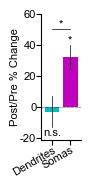

In [32]:
figName = 'Fig6_selectivity_perChange.pdf'
fontsize = 8
figsize = [0.5,1.4]
fig, ax = jsm.clean_subplots(1,1,figsize=figsize,facecolor='none',constrained_layout = False)
pColors = [(1,0,0),(0,1,0),(0,0,0)]
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
barwidth = 0.1
pLabels = ['Early', 'Late','Late-Early']
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap mean±SEM"
elif error == 'std':
    errorLabel = "bootstrap mean±SD"

testLine = 0
niceAnatLabels = ['Dendrites','Somas']
window = [1,6.2]
plotLims = [-3.6,3.6]
allDists = {}
allPs = {}
alphas = [0.3,0.6]
ylim = [-21,60]
testLS = ':'
testLW = 0.5
testColor = (0,0,0)
testAlpha = 0.5
testDashes = (5,1)

ax.spines[['top','right']].set_visible(False)
ax.axhline(testLine, lw = testLW, color = testColor, linestyle = testLS, alpha = testAlpha,dashes=testDashes)
ax.set_ylim(ylim)
for ak, anat in enumerate(anatKeys):
    allPs[anat] = {}
    F = frs[ak]/factors[ak]
    pre = allSels[anat]['pre']
    preMean = np.nanmean(pre[:,int(window[0]*F):int(window[1]*F)], axis = 1)
    post = allSels[anat]['post']
    postMean = np.nanmean(post[:,int(window[0]*F):int(window[1]*F)], axis = 1)
    ratio = postMean/preMean
    wData = (ratio-1)*100#ratio
    wData = (postMean-preMean)/np.absolute(preMean)*100#ratio
    allDists[anat] = wData
    
    mean = np.nanmean(wData,axis=0)
    med = np.nanmedian(wData,axis=0)
    std = np.nanstd(wData,axis=0, ddof = 1)
    sem = std / np.sqrt(wData.shape[0])
    low,high = np.nanpercentile(wData, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
    if error == 'CI':
        mainPlot = med
        errorLow = low
        errorHigh = high
    elif error == 'sem':
        mainPlot = mean
        errorLow = mean-sem
        errorHigh = mean+sem
    elif error == 'std':
        mainPlot = mean
        errorLow = mean-std
        errorHigh = mean+std

    testLine = 0
        
    tail1 = np.sum(wData<testLine)/wData.shape[0]
    tail2 = np.sum(wData>testLine)/wData.shape[0]
    twoTails = 2 * min(tail1, tail2)
    pVal = min(twoTails, 1.0)
    pText = jsm.pstar(pVal,inclP = False)
    allPs[anat]=pVal
    print(anat, f'mean: {np.nanmean(wData):.03f}', f'std: {np.nanstd(wData):.03f}', f'pVal: {pVal:.03f}')

    x = ak/4
    ax.bar(x, mainPlot, width = 0.2, color = aColors[ak], alpha = 1)
    ax.plot([x,x],[errorLow,errorHigh],color = (0,0,0),lw = linewidth)
    if mainPlot<testLine:
        text_ypos = errorLow
        va='top'
    else:
        text_ypos = errorHigh
        va = 'bottom'

    ax.text(x, text_ypos, pText, fontsize=fontsize,ha='center',va=va)
                
dData = allDists['dendrites']
sData = allDists['somas']

pVal = np.sum(sData<dData)/wData.shape[0]
pText = jsm.pstar(pVal,inclP = False)
print('anat comp', f'{pVal:.03f}')

topBarY = 50
ys = [topBarY,topBarY]
ax.plot([0,0.25],[ys[0],ys[0]], lw = linewidth, color = (0,0,0))
ax.text(.125,ys[0],pText,fontsize=fontsize,ha='center',va='bottom')
ax.set_xlim([-0.15,0.4])
ax.set_xticks([0,0.25])
ax.tick_params(axis='y', which='major', labelsize=fontsize) #

ax.set_ylabel('Post/Pre % Change',fontsize=fontsize,labelpad=0)
ax.set_xticklabels(niceAnatLabels,fontsize=fontsize-2,rotation=30,ha='right',va='top',rotation_mode='anchor')
ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 0) #
ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 0) #
pos = ax.get_position()
print(pos)
ax.set_position([0.125,0,0.8,0.9])
with maybe_pdf(os.path.join(FIG_EXPORT_DIR,figName)) as pdf:
    pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
jsm.display_clean_subplots(fig,ax)

# preLate, postEarly, postLate

In [33]:

thrsh = 0.05
minTrials = 10
anatKeys = ['dendrites', 'somas']

aAnms, keepRoisFull, keepRoisDS, allNaNs = jsm.check_anms_ROIs(allAnmParams, anms, anatKeys, dffKey, thrsh)
aAnms, iAnms, anmsMinTrial, allMinTrials = jsm.check_trials(allAnmParams, anms, anatKeys, dffKey, minTrials)

full
dendrites 327 / 402 0.813
somas 479 / 528 0.907

dendrites B00002121774 334 264 74 15
dendrites B00002213772 350 361 34 72
dendrites B00002213773 190 196 32 67
dendrites B00002213784 308 260 20 23
dendrites B00002213785 271 264 43 68
dendrites B00002213908 266 242 43 41
dendrites B00002213909 337 306 142 47
dendrites B00002213921 254 301 51 47
dendrites B00002213943 311 340 24 50
dendrites B00002213998 366 28 148 17
somas B00002121749 164 41 45 15
somas B00002121774 238 229 58 35
somas B00002213772 258 288 25 74
somas B00002213773 107 80 18 19
somas B00002213785 235 250 25 49
somas B00002213889 321 229 59 22
somas B00002213908 270 227 103 73
somas B00002213909 251 198 142 18
somas B00002213921 281 290 23 20
somas B00002213943 286 275 29 20
somas B00002213997 187 83 256 18
somas B00002213999 287 207 15 12
12
Finished processing trials.


### megaTsep calc

In [34]:

iAnms = {}
aAnms = {}
minTrials = 25
allMinTrials = []
anmsMinTrial = {}
for anat in anatKeys:
    iAnms[anat] = []
    aAnms[anat] = []
    anmsMinTrial[anat] = {}
    for anm in anms:
        if anat in list(allAnmParams[anm][dffKey]['dsTsep'].keys()):

            dsTsep = allAnmParams[anm][dffKey]['dsTsep'][anat]['full']

            aAnms[anat].append(anm)
            tracker = allAnmParams[anm]['tracker']
            dendDays = allAnmParams[anm]['dendDays']
            preLateMask = allAnmParams[anm]['shiftMask']['preShift_late']
            earlyMask = allAnmParams[anm]['shiftMask']['early']
            lateMask = allAnmParams[anm]['shiftMask']['late']
            
            if anat == 'dendrites':
                anatMask = dendDays
            else:
                anatMask = ~dendDays

            earlyAnatMask = np.logical_and(anatMask, earlyMask)
            lateAnatMask = np.logical_and(anatMask, lateMask)
            preLateAnatMask = np.logical_and(anatMask, preLateMask)
            earlytkr = tracker[earlyAnatMask,:]
            latetkr = tracker[lateAnatMask,:]

            eCR = np.sum(earlytkr[:,2]==0)
            eCL = np.sum(earlytkr[:,2]==1)
            lCR = np.sum(latetkr[:,2]==0)
            lCL = np.sum(latetkr[:,2]==1)
            preLateCR = np.sum(tracker[preLateAnatMask,2]==0)
            preLateCL = np.sum(tracker[preLateAnatMask,2]==1)

            if np.all(np.hstack([item>minTrials for item in [preLateCR, preLateCL, eCR, eCL, lCR, lCL]])):
                if anm != 'B00002121777':
                    if dsTsep.shape[1]>=10:
                        iAnms[anat].append(anm)
                        print(anat, anm, preLateCR, preLateCL, np.sum(eCR), np.sum(eCL), np.sum(lCR), np.sum(lCL))
                        allMinTrials.append(np.hstack([preLateCR, preLateCL, eCR,eCL,lCR,lCL]))
                        anmsMinTrial[anat][anm] = np.min(np.hstack([preLateCR, preLateCL, eCR,eCL,lCR,lCL]))
print(np.min(np.hstack(allMinTrials)))

dendrites B00002121774 41 42 152 147 143 97
dendrites B00002213772 135 135 111 84 174 112
dendrites B00002213784 37 33 74 60 153 105
dendrites B00002213908 157 103 101 71 77 67
dendrites B00002213920 101 91 110 109 135 117
dendrites B00002213985 39 55 91 113 157 137
dendrites B00002213997 145 95 72 49 97 72
dendrites B00002213999 49 34 67 45 142 93
somas B00002121774 126 116 53 52 139 96
somas B00002213772 40 46 82 53 173 95
somas B00002213784 145 113 131 89 112 91
somas B00002213785 95 140 64 57 102 83
somas B00002213889 45 46 100 71 126 68
somas B00002213908 38 26 93 58 119 71
somas B00002213920 58 39 114 72 115 127
somas B00002213982 148 140 101 99 124 101
somas B00002213999 154 118 117 84 159 106
26


In [35]:
psWindow = [-3.6,3.6]
useDS = True
anmsToUse = iAnms
shuffAnms = True
shuffRois = False
enforceMinTrial = False
binary = False

allAnms = np.unique(np.hstack([anmsToUse[anat] for anat in anatKeys]))
phases = ['preShift_late', 'early', 'late']
mods = ['GO','CT']#,'errGO', 'errCT']
alignTimes = ['goCues','cTimes']#,'goCues','cTimes']
print('Prepping megaTseps...')
nBoot = 10000
megaTseps = {}
megaTsepsHH = {}
emptyMegaTsep = {'dendrites': [], 'somas': []}

for p, phase in enumerate(phases):
    megaTseps[phase] = {}
    megaTsepsHH[f'{phase}1'] = {}
    megaTsepsHH[f'{phase}2'] = {}
    for mod in mods:
        megaTseps[phase][mod] = copy.deepcopy(emptyMegaTsep)
        megaTsepsHH[f'{phase}1'][mod] = copy.deepcopy(emptyMegaTsep)
        megaTsepsHH[f'{phase}2'][mod] = copy.deepcopy(emptyMegaTsep)

print('Making holder matrices...')
#making holder matracies
somaTime = allAnmParams[anmsToUse['somas'][0]][dffKey]['dsTsep']['somas']['go-psTsep'].shape[2]
nSoma = 0
for anm in anmsToUse['somas']:
    nSoma+=allAnmParams[anm][dffKey]['dsTsep']['somas']['go-psTsep'][:,keepRoisDS['somas'][anm],:].shape[1]
    
dendTime = allAnmParams[anmsToUse['dendrites'][0]][dffKey]['dsTsep']['dendrites']['go-psTsep'].shape[2]
nDend = 0
for anm in anmsToUse['dendrites']:
    nDend+=allAnmParams[anm][dffKey]['dsTsep']['dendrites']['go-psTsep'][:,keepRoisDS['dendrites'][anm],:].shape[1]

somaEmpty = np.empty([4, somaTime, nSoma, nBoot])
dendEmpty = np.empty([4, dendTime, nDend, nBoot])
empties = [dendEmpty, somaEmpty]
for phase in phases:
    for mod in mods:
        for ak, anat in enumerate(anatKeys):
            print(phase, mod, anat)
            megaTseps[phase][mod][anat] = copy.deepcopy(empties[ak])
            megaTsepsHH[f'{phase}1'][mod][anat] = copy.deepcopy(empties[ak])
            megaTsepsHH[f'{phase}2'][mod][anat] = copy.deepcopy(empties[ak])
print('Starting bootstrapping...')
for i in tqdm(range(nBoot)):
    for ak, anat in enumerate(anatKeys):
        if shuffAnms:
            anmIdxs = np.random.choice(np.arange(len(anmsToUse[anat])), len(anmsToUse[anat]))
        else:
            anmIdxs = np.arange(len(anmsToUse[anat]))
        nRois = np.sum(np.hstack([np.sum(keepRoisDS[anat][anm]) for anm in anmsToUse[anat]]))
        for m, mod in enumerate(mods):
            if 'err' in mod:
                returnErrors = True
            else:
                returnErrors = False
            mT = jsm.gather_anmShuff_megaTsepFull(allAnmParams, anat, ak, mod, phases, frs, keepRoisDS, dffKey, alignTimes[m], anmsToUse, nRois,
                                                  anmIdxs, enforceMinTrial, binary, returnErrors, anmsMinTrial)
            
            mT1, mT2 = jsm.gather_anmShuff_megaTsepHH(allAnmParams, anat, ak, mod, phases, frs,  keepRoisDS, dffKey, alignTimes[m], anmsToUse, nRois,
                                                  anmIdxs, enforceMinTrial, binary, returnErrors, anmsMinTrial)
            for phase in phases:
                megaTseps[phase][mod][anat][:,:,:,i] = mT[phase]
                megaTsepsHH[f'{phase}1'][mod][anat][:,:,:,i] = mT1[phase]
                megaTsepsHH[f'{phase}2'][mod][anat][:,:,:,i] = mT2[phase]

Prepping megaTseps...
Making holder matrices...
preShift_late GO dendrites
preShift_late GO somas
preShift_late CT dendrites
preShift_late CT somas
early GO dendrites
early GO somas
early CT dendrites
early CT somas
late GO dendrites
late GO somas
late CT dendrites
late CT somas
Starting bootstrapping...


  0%|          | 0/10000 [00:00<?, ?it/s]

/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/functions/js_manuscript_final.py:3155: RuntimeWarning: Mean of empty slice
  nanMask = np.any(np.isfinite(coors),axis = 1)
/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/functions/js_manuscript_final.py:3368: RuntimeWarning: Mean of empty slice
  tracker = allAnmParams[anm]['tracker']


In [36]:
for ak, anat in enumerate(anatKeys):
    print(anat, len(anmsToUse[anat]))
    for phase in phases:
       print(anat," ",phase," ", megaTsepsHH[f'{phase}2'][mod][anat].shape)

dendrites 8
dendrites   preShift_late   (4, 32, 161, 10000)
dendrites   early   (4, 32, 161, 10000)
dendrites   late   (4, 32, 161, 10000)
somas 9
somas   preShift_late   (4, 34, 211, 10000)
somas   early   (4, 34, 211, 10000)
somas   late   (4, 34, 211, 10000)


In [37]:
%%time
CRCL = {}
sqrt = False
nBoot = 10000
for ak, anat in enumerate(anatKeys):
    CRCL[anat] = {}
    for calcPhase in ['pre1','pre2','early1','early2','late1','late2']:#, 'errL']:#', 'early1', 'early2']:#, 'late1', 'late2']:
        CRCL[anat][calcPhase] = {}
        for m, mod in enumerate(['CT','GO']):#,'LL']):
            print('starting', anat, calcPhase, mod)
            allData = jsm.get_CRCL_CD_fast_earlyLate(megaTsepsHH, anat, mod, calcPhase=calcPhase, sqrt = sqrt, nBoot = nBoot)
            CRCL[anat][calcPhase][mod] = allData
print('done')

starting dendrites pre1 CT
starting dendrites pre1 GO
starting dendrites pre2 CT
starting dendrites pre2 GO
starting dendrites early1 CT
starting dendrites early1 GO
starting dendrites early2 CT
starting dendrites early2 GO
starting dendrites late1 CT
starting dendrites late1 GO
starting dendrites late2 CT
starting dendrites late2 GO
starting somas pre1 CT
starting somas pre1 GO
starting somas pre2 CT
starting somas pre2 GO
starting somas early1 CT
starting somas early1 GO
starting somas early2 CT
starting somas early2 GO
starting somas late1 CT
starting somas late1 GO
starting somas late2 CT
starting somas late2 GO
done
CPU times: user 2min 25s, sys: 3.3 s, total: 2min 28s
Wall time: 2min 28s


In [38]:
%%time
CRCL_full = {}
nBoot = 10000
for ak, anat in enumerate(anatKeys):
    CRCL_full[anat] = {}
    for calcPhase in ['pre','early','late']:
        CRCL_full[anat][calcPhase] = {}
        for m, mod in enumerate(['CT','GO']):
            print('starting', anat, calcPhase, mod)
            allData = jsm.get_CRCL_CD_full(megaTseps,anat, mod, calcPhase = calcPhase, nBoot = nBoot)
            CRCL_full[anat][calcPhase][mod] = allData
print('done')

starting dendrites pre CT
starting dendrites pre GO
starting dendrites early CT
starting dendrites early GO
starting dendrites late CT
starting dendrites late GO
starting somas pre CT
starting somas pre GO
starting somas early CT
starting somas early GO
starting somas late CT
starting somas late GO
done
CPU times: user 42.4 s, sys: 1.06 s, total: 43.5 s
Wall time: 43.7 s


#### 4 windows

/tmp/ipykernel_1194786/1935045764.py:110: RuntimeWarning: invalid value encountered in sqrt
  denom = np.sqrt(preCorr*postCorr)


MultCompar Correction method = fdr_bh alpha = 0.05
pVals      = [0.5133 0.8042 0.5762 0.3741 0.6203 0.6575 0.0286 0.4503 0.3026 0.7378
 0.3656 0.5126 0.9868 0.413  0.2095 0.2537 1.     0.8194 0.8035 0.8661
 0.9971 0.7459 0.4906 0.1655 0.1868 0.435  0.7603 0.3891 0.4911 0.0599
 0.1291 0.2494]
pVals_Corr = [0.86450526 0.93645714 0.92192    0.86450526 0.93645714 0.93645714
 0.86450526 0.86450526 0.86450526 0.93645714 0.86450526 0.86450526
 1.         0.86450526 0.86450526 0.86450526 1.         0.93645714
 0.93645714 0.95569655 1.         0.93645714 0.86450526 0.86450526
 0.86450526 0.86450526 0.93645714 0.86450526 0.86450526 0.86450526
 0.86450526 0.86450526]
MultCompar Correction method = fdr_bh alpha = 0.05
pVals      = [0.2467 0.0222 0.0235 0.091  0.3228 0.6812 0.9857 0.7771 0.7031 0.8645
 0.5922 0.4975 0.4075 0.8673 0.8019 0.4262 0.369  0.0088 0.0172 0.0061
 0.014  0.2544 0.1782 0.1669 0.3014 0.1811 0.4403 0.6416 0.7636 0.9148
 0.4972 0.4941]
pVals_Corr = [0.6784     0.12533333 0.1253

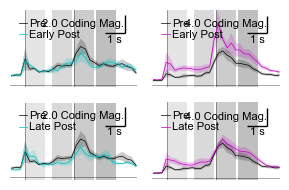

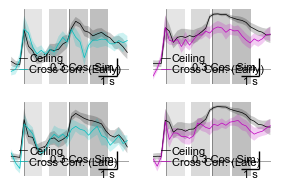

In [42]:
figSize = [3,2]
fontsize = 8

magFig, magAxs = jsm.clean_subplots(2,2,figSize, facecolor='none',constrained_layout = False)
corFig, corAxs = jsm.clean_subplots(2,2,figSize, facecolor='none',constrained_layout = False)
linewidth = 0.5
allFigs = [magFig, corFig]
allAxs = [magAxs, corAxs]
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
pColors = [(0,0,0),(1,0,0),(0,0.75,0)]
pColors = [(0,0,0),(0.5,0.25,0),(0.5,0.5,0)]
titles = ['Coding Mag.', 'Cos. Sim.']
windowLabels = ['Sensory Cues', 'Delay', 'Response', 'Late Response']
niceAnatLabels = ['Dendrites', 'Somas']
labels = ['Early Post','Late Post']
alpha = 0.05
method='fdr_bh'
mod = 'GO'
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap\nmedian±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap\nmean±SEM"
elif error == 'std':
    errorLabel = "boot. mean±SD"

verobse = False
windows = [[3.6,4.6]]
windows = [[1.15,2.15],[2.5,3.5],[3.6,4.6],[4.7,5.7]]
plotLims = [-3.6,3.6]
xlim = [-3.2,3.2]
ylims = [[[-0.3,8],[-0.5,17]],[[-0.25,1],[-0.25,1]]]
xticks = np.arange(7)-3
linewidth = 0.5

plot_scaleBar={}
plot_scaleBar['corner']='BR'
plot_scaleBar['length_s'] = 1
plot_scaleBar['height_per'] = 0.25
plot_scaleBar['lw'] = 1
plot_scaleBar['fontsize'] = fontsize
plot_scaleBar['includeLabel'] = True

markerLS = '-'
markerLW = 0.5
markerColor = (0,0,0)
markerAlpha = 0.5

for aS, axSet in enumerate(allAxs):
    for ak in range(2):
        for a, ax in enumerate(axSet[:,ak]):
            ax.set_ylim(ylims[aS][ak])            
            ax.set_xlim(xlim)
            
            if mod == 'GO':
                alignTime = 'Go Cue'
                markers = [0,-1.25,-2.45]
                markers = [0,-2.45]
            else:
                alignTime = 'Contact'
                markers = [0]
            for mark in markers:
                ax.plot([mark]*2,ylims[aS][ak],lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
            ax.axhline(0, lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
            for w, window in enumerate(windows):
                ax.fill_between(np.hstack(window)-3.6,[ylims[aS][ak][0]]*2, [ylims[aS][ak][1]]*2, color = (0,0,0), alpha = w*0.05+0.1, edgecolor='none')
            vertLabel = titles[aS]+'\n('+errorLabel+')'
            vertLabel = titles[aS]
            if aS == 0:
                plot_scaleBar['horzAdjust']=0.1
                plot_scaleBar['vertAdjust']=0.7
            else:
                plot_scaleBar['horzAdjust']=0.1
                plot_scaleBar['vertAdjust']=0.1

            ax,plot_scaleBar = jsm.add_plot_scaleBar(ax,plot_scaleBar,(0,0,0),True,vertLabel)

    for ax in axSet.flatten():
        ax.spines[['top','right','left','bottom']].set_visible(False)

allPs = {}
for ak, anat in enumerate(anatKeys):
    allPs[anat] = {}
    for p, phase in enumerate(phases[1:]):
        allPs[anat][phase] = {}

        if p == 0:
            labelMod = 'Early'
        else:
            labelMod = 'Late'
        labels = [['Pre',labelMod+" Post"],['Ceiling', f'Cross Corr. ({labelMod})']]

        pre1 = CRCL[anat][f'pre1'][mod]['axesOrig']#boot, time, roi
        pre2 = CRCL[anat][f'pre2'][mod]['axesOrig']
        post1 = CRCL[anat][f'{phase}1'][mod]['axesOrig']
        post2 = CRCL[anat][f'{phase}2'][mod]['axesOrig']
    
        preFull = CRCL_full[anat]['pre'][mod]['axesOrig']
        preNorm = np.linalg.norm(preFull, axis=2)
        postFull = CRCL_full[anat][f'{phase}'][mod]['axesOrig']
        postNorm = np.linalg.norm(postFull, axis=2)
    
        magDif = postNorm-preNorm
    
        preMag, preCorr = jsm.get_mag_corr(pre1, pre2)
        postMag, postCorr = jsm.get_mag_corr(post1, post2)
        mixMag, mixCorr = jsm.get_mag_corr(preFull,postFull)
    
        denom = np.sqrt(preCorr*postCorr)
        mixCorrected = mixCorr/(denom)
    
        mags = [preNorm, postNorm]
        corrs = [denom, mixCorr]
        data2Plot = [mags,corrs]
    
        magDiff = mags[1]-mags[0]
    
        magP = np.sum(magDiff<0, axis=0)/magDiff.shape[0]
        magCorrection_multCorr,magCorrection_pText = jsm.multi_test_correction(magP,method,alpha,verobse)

        allPs[anat][phase]['mag'] = magP
        
        corrP = np.sum(mixCorrected>1, axis = 0)/mixCorrected.shape[0]
        mixCorrection_multCorr,mixCorrection_pText = jsm.multi_test_correction(corrP,method,alpha,verobse)
        allPs[anat][phase]['corr'] = corrP

        for d, dataSet in enumerate(data2Plot):
            if p == 0 and d == 0:
                col = 0
            elif p == 0 and d ==1:
                col = 2
            elif p == 1 and d == 0:
                col = 1
            else:
                col = 3
            ax = allAxs[d][p,ak]
            for j, data in enumerate(dataSet):
                if j == 0:
                    color = (0,0,0)
                else:
                    color = aColors[ak]
                mean = np.nanmean(data,axis=0)
                med = np.nanmedian(data,axis=0)
                std = np.nanstd(data,axis=0, ddof = 1)
                sem = std / np.sqrt(data.shape[0])
                low,high = np.nanpercentile(data, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
                x = np.linspace(plotLims[0],plotLims[1],len(mean))
                plotIdx = np.arange(np.argmin(np.absolute(x-xlim[0])),np.argmin(np.absolute(x-xlim[1]))+1)
                if error == 'CI':
                    mainPlot = med
                    errorLow = low
                    errorHigh = high
                elif error == 'sem':
                    mainPlot = mean
                    errorLow = mean-sem
                    errorHigh = mean+sem
                elif error == 'std':
                    mainPlot = mean
                    errorLow = mean-std
                    errorHigh = mean+std

                ax.fill_between(x[plotIdx], errorLow[plotIdx], errorHigh[plotIdx], color = color, alpha = 0.2, edgecolor='none')
                ax.plot(x[plotIdx], mainPlot[plotIdx], ls = '-',color = color, label = labels[d][j],lw = linewidth)
            ax.set_yticks([])
            ax.set_xticks([])
            ax.set_xlim(xlim)
            ax.set_ylim(ylims[d][ak])
            if d == 0:
                loc = 'upper left'
            else:
                loc = 'lower left'
            ax.legend(frameon=False,fontsize=fontsize,loc=loc,handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 

figName = 'Fig6_earlyLate_magProjections_4windows.pdf'
with maybe_pdf(os.path.join(FIG_EXPORT_DIR,figName)) as pdf:
    pdf.savefig(magFig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
jsm.display_clean_subplots(magFig,magAxs)
figName = 'Fig6_earlyLate_cosProjections_4windows.pdf'
with maybe_pdf(os.path.join(FIG_EXPORT_DIR,figName)) as pdf:
    pdf.savefig(corFig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
jsm.display_clean_subplots(corFig,corAxs)

/tmp/ipykernel_1194786/887753467.py:56: RuntimeWarning: invalid value encountered in sqrt
  denomEarly = np.sqrt(preCorr*earlyCorr)
/tmp/ipykernel_1194786/887753467.py:58: RuntimeWarning: invalid value encountered in sqrt
  denomLate = np.sqrt(preCorr*lateCorr)
/tmp/ipykernel_1194786/887753467.py:61: RuntimeWarning: invalid value encountered in sqrt
  withinDenom = np.sqrt(earlyCorr*lateCorr)
/tmp/ipykernel_1194786/887753467.py:75: RuntimeWarning: Mean of empty slice
  wData = np.nanmean(data[:,int(window[0]*F):int(window[1]*F)], axis = 1)/np.nanmean(denom[:,int(window[0]*F):int(window[1]*F)], axis = 1)


dendrites
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.2026 0.4004 0.007  0.1444]
pVals_Corr = [0.4332 0.4332 0.028  0.4332]
dendrites
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.6156 0.2578 0.002  0.0354]
pVals_Corr = [0.6156 0.5156 0.008  0.1062]
dendrites
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.4684 0.0364 0.0074 0.2168]
pVals_Corr = [0.4684 0.1092 0.0296 0.4336]
somas
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.5092 0.2692 0.     0.0006]
pVals_Corr = [0.5384 0.5384 0.     0.0018]
somas
MultCompar Correction method = holm alpha = 0.05
pVals      = [2.552e-01 2.362e-01 0.000e+00 2.000e-04]
pVals_Corr = [0.4724 0.4724 0.     0.0006]
somas
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.428  0.1286 0.     0.    ]
pVals_Corr = [0.428  0.2572 0.     0.    ]
Early Post-Shift
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.9052 0.9026 0.2511 0.6674]
pVals_Corr = [1. 1. 1

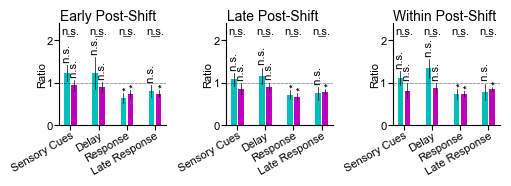

In [44]:
figSize = (5,1.75)
fontsize = 8
fig, axs = jsm.clean_subplots(1,3,figSize, sharey = False, constrained_layout = True)
pColors = [(1,0,0),(0,1,0),(1,0,1)]
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
barwidth = 0.2
windowLabels = ['Sensory Cues', 'Delay', 'Response', 'Late Response']
pLabels = ['Early Post-Shift', 'Late Post-Shift','Within Post-Shift']
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap mean±SEM"
elif error == 'std':
    errorLabel = "bootstrap mean±SD"
niceAnatLabels = ['Dendrites','Somas']
windows = [[1.15,2.15],[2.5,3.5],[3.6,4.6],[4.7,5.7]]
mod = 'GO'
nWindows = len(windows)
testLS = ':'
testDashes = (5,1)
testLW = 0.5
testColor = (0,0,0)
testAlpha = 0.5

nWindows = len(windows)
allDists = {}
allPs = {}
alphas = [1,1]
postShiftRaw = []
postShiftIntCorr = []
for ak, anat in enumerate(anatKeys):
    allDists[anat] = {}
    allPs[anat] = {}
    F = frs[ak]/factors[ak]
    pre1 = CRCL[anat][f'pre1'][mod]['axesOrig']#boot, time, roi
    pre2 = CRCL[anat][f'pre2'][mod]['axesOrig']
    early1 = CRCL[anat][f'early1'][mod]['axesOrig']
    early2 = CRCL[anat][f'early2'][mod]['axesOrig']
    late1 = CRCL[anat][f'late1'][mod]['axesOrig']
    late2 = CRCL[anat][f'late2'][mod]['axesOrig']

    preFull = CRCL_full[anat]['pre'][mod]['axesOrig']
    earlyFull = CRCL_full[anat][f'early'][mod]['axesOrig']
    lateFull = CRCL_full[anat][f'late'][mod]['axesOrig']
    
    preMag, preCorr = jsm.get_mag_corr(pre1, pre2)
    earlyMag, earlyCorr = jsm.get_mag_corr(early1, early2)
    lateMag, lateCorr = jsm.get_mag_corr(late1, late2)

    mixEarlyMag, mixEarlyCorr = jsm.get_mag_corr(preFull,earlyFull)
    mixLateMag, mixLateCorr = jsm.get_mag_corr(preFull,lateFull)
    mixMixMag, mixMixCorr = jsm.get_mag_corr(earlyFull,lateFull)

    denomEarly = np.sqrt(preCorr*earlyCorr)
    mixEarlyCorrected = mixEarlyCorr/(denomEarly) #boot, time
    denomLate = np.sqrt(preCorr*lateCorr)
    mixLateCorrected = mixLateCorr/(denomLate)

    withinDenom = np.sqrt(earlyCorr*lateCorr)
    mixMixCorrected = mixMixCorr/withinDenom
    data2Plot = [mixEarlyCorr, mixLateCorr, mixMixCorr]
    denoms = [denomEarly, denomLate, withinDenom]

    for d, data in enumerate(data2Plot):
        ax = axs[d]
        allDists[anat][pLabels[d]] = []#data
        denom = denoms[d]

        anatMains = np.zeros(nWindows)
        anatErrors = np.zeros([2,nWindows])
        anatPs = np.zeros(nWindows)
        for w, window in enumerate(windows):
            wData = np.nanmean(data[:,int(window[0]*F):int(window[1]*F)], axis = 1)/np.nanmean(denom[:,int(window[0]*F):int(window[1]*F)], axis = 1)
            allDists[anat][pLabels[d]].append(wData)

            mean = np.nanmean(wData,axis=0)
            med = np.nanmedian(wData,axis=0)
            std = np.nanstd(wData,axis=0, ddof = 1)
            sem = std / np.sqrt(wData.shape[0])
            low,high = np.nanpercentile(wData, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
            if error == 'CI':
                mainPlot = med
                errorLow = low
                errorHigh = high
            elif error == 'sem':
                mainPlot = mean
                errorLow = mean-sem
                errorHigh = mean+sem
            elif error == 'std':
                mainPlot = mean
                errorLow = mean-std
                errorHigh = mean+std

            anatMains[w] = copy.deepcopy(mainPlot)
            anatErrors[0,w] = copy.deepcopy(errorLow)
            anatErrors[1,w] = copy.deepcopy(errorHigh)
            
            testLine = 1
                
            tail1 = np.sum(wData<testLine)/wData.shape[0]
            tail2 = np.sum(wData>testLine)/wData.shape[0]
            twoTails = 2 * min(tail1, tail2)
            pVal = min(twoTails, 1.0)
            anatPs[w] = pVal
            
        allPs[anat][pLabels[d]]=anatPs

        print(anat)
        multCorr,anatPText = jsm.multi_test_correction(anatPs,method='holm',alpha = 0.05,verbose = True)

        ax.bar(np.arange(nWindows)+(ak/4), anatMains, width = barwidth, color = aColors[ak], alpha = alphas[ak])
        for i in range(nWindows):
            ax.plot(np.array([i,i])+(ak/4),anatErrors[:,i],color = (0,0,0),lw = linewidth)
            if anatMains[i]<0:
                text_ypos = anatErrors[0,i]
                va='top'
            else:
                text_ypos = anatErrors[1,i]
                va = 'bottom'
            if 'n.s.' in anatPText[i]:
                ha='center'
            else:
                ha='left'
            rotation = 90
            ax.text(i+(ak/4), text_ypos, " "+anatPText[i], fontsize=fontsize,ha=ha,va=va,rotation = rotation)
for a, ax in enumerate(axs):
    ax.spines[['top','right']].set_visible(False)
    testLine = 1
    ax.axhline(testLine, lw = testLW, color = testColor, linestyle = testLS, alpha = testAlpha,dashes=testDashes)

ys = [2.1,2.1,2.1]
for d in range(3):
    ax = axs[d]
    y = ys[d]
    pVals = []
    for w in range(nWindows):
        dData = allDists['dendrites'][pLabels[d]][w]
        sData = allDists['somas'][pLabels[d]][w]
        
        pVal = np.sum(sData<dData)/wData.shape[0]
        pVals.append(pVal)

    pVals = np.hstack(pVals)

    print(pLabels[d])
    multCorr,pText = jsm.multi_test_correction(pVals,method='holm',alpha = 0.05,verbose = True)
    for w in range(nWindows):
        ax.plot([w,w+0.25],[y,y], lw = linewidth, color = (0,0,0))
        ax.text(w+.125,y,pText[w],fontsize=fontsize,ha='center',va='bottom')
    ax.set_xticks(np.arange(4)+.12)
    ax.set_xticklabels(windowLabels,fontsize=fontsize,rotation=30,ha='right',va='top',rotation_mode='anchor')
    ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 0) #
    ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 1) #
    ax.set_ylim([0,2.4])
    ax.text(-0.25,2.4,pLabels[d],fontsize=fontsize+2,ha='left',va='bottom')
    ax.set_ylabel('Ratio',fontsize=fontsize,labelpad=0)
figName = 'Fig6_earlyLate_cosStat_4windows.pdf'
with maybe_pdf(os.path.join(FIG_EXPORT_DIR,figName)) as pdf:
    pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
jsm.display_clean_subplots(fig,axs)

#### 4 windows Percent Change Aaron this is the lastest version

----------------
dendrites Early Post-Shift vs. Pre Sensory Cues vs Response two tails pval 0.0222
----------------
dendrites Early Post-Shift vs. Pre 2tail v 0
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.344  0.8352 0.1024 0.8084]
pVals_Corr = [1.     1.     0.4096 1.    ]
----------------
dendrites Late Post-Shift vs Pre Sensory Cues vs Response two tails pval 0.0784
----------------
dendrites Late Post-Shift vs Pre 2tail v 0
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.3838 0.     0.0696 0.9418]
pVals_Corr = [0.7676 0.     0.2088 0.9418]
----------------
dendrites Late-Early Sensory Cues vs Response two tails pval 0.5092
----------------
dendrites Late-Early 2tail v 0
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.59   0.0072 0.6988 0.9462]
pVals_Corr = [1.     0.0288 1.     1.    ]
----------------
somas Early Post-Shift vs. Pre Sensory Cues vs Response two tails pval 0.0522
----------------
somas Early Post-Shift vs. Pre 2

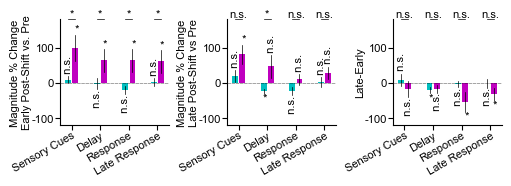

In [45]:
figSize = (5,1.75)
fontsize = 8
fig, axs = jsm.clean_subplots(1,3,figSize, sharey = False, constrained_layout = True)
pColors = [(1,0,0),(0,1,0),(0,0,0)]
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
ylim = [-120,180]
ys = [180,180,180]
barwidth = 0.2
windowLabels = ['Sensory Cues', 'Delay', 'Response', 'Late Response']
pLabels = ['Early Post-Shift vs. Pre', 'Late Post-Shift vs Pre','Late-Early']
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap mean±SEM"
elif error == 'std':
    errorLabel = "bootstrap mean±SD"
niceAnatLabels = ['Dendrites','Somas']
windows = [[1.15,2.15],[2.5,3.5],[3.6,4.6],[4.7,5.7]]
mod = 'GO'
dataType = 'Magnitude'
nWindows = len(windows)
testLS = ':'
testDashes = (5,1)
testLW = 0.5
testColor = (0,0,0)
testAlpha = 0.5

allDists = {}
allPs = {}
alphas = [1,1]
for ak, anat in enumerate(anatKeys):
    
    allDists[anat] = {}
    allPs[anat] = {}
    F = frs[ak]/factors[ak]
    pre = np.linalg.norm(CRCL_full[anat]['pre'][mod]['axesOrig'], axis = 2)
    early = np.linalg.norm(CRCL_full[anat]['early'][mod]['axesOrig'], axis = 2)
    late = np.linalg.norm(CRCL_full[anat]['late'][mod]['axesOrig'], axis = 2)
    earlyPer = (early-pre)/np.absolute(pre) * 100
    latePer = (late-pre)/np.absolute(pre) * 100
    post_pre = latePer-earlyPer
    data2Plot = [earlyPer, latePer, post_pre]
    for d, data in enumerate(data2Plot):
        ax = axs[d]
        allDists[anat][pLabels[d]] = []#data

        anatMains = np.zeros(nWindows)
        anatErrors = np.zeros([2,nWindows])
        anatPs = np.zeros(nWindows)
        for w, window in enumerate(windows):
            wData = np.nanmean(data[:,int(window[0]*F):int(window[1]*F)], axis = 1)
            allDists[anat][pLabels[d]].append(wData)

            mean = np.nanmean(wData,axis=0)
            med = np.nanmedian(wData,axis=0)
            std = np.nanstd(wData,axis=0, ddof = 1)
            sem = std / np.sqrt(wData.shape[0])
            low,high = np.nanpercentile(wData, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
            if error == 'CI':
                mainPlot = med
                errorLow = low
                errorHigh = high
            elif error == 'sem':
                mainPlot = mean
                errorLow = mean-sem
                errorHigh = mean+sem
            elif error == 'std':
                mainPlot = mean
                errorLow = mean-std
                errorHigh = mean+std

            anatMains[w] = copy.deepcopy(mainPlot)
            anatErrors[0,w] = copy.deepcopy(errorLow)
            anatErrors[1,w] = copy.deepcopy(errorHigh)
            
            testLine = 0
                
            tail1 = np.sum(wData<testLine)/wData.shape[0]
            tail2 = np.sum(wData>testLine)/wData.shape[0]
            twoTails = 2 * min(tail1, tail2)
            pVal = min(twoTails, 1.0)
            anatPs[w] = pVal

        w1 = 0
        data1 = allDists[anat][pLabels[d]][w1]
        w2 = 2
        data2 = allDists[anat][pLabels[d]][w2]
        tail1 = np.sum(data1<data2)/data1.shape[0]
        tail2 = np.sum(data1>data2)/data1.shape[0]
        twoTails = 2 * min(tail1, tail2)
        pVal = min(twoTails, 1.0)
        print('----------------')
        print(f'{anat} {pLabels[d]} {windowLabels[w1]} vs {windowLabels[w2]} two tails pval {pVal}')
        allPs[anat][pLabels[d]]=anatPs
        print('----------------')
        print(f'{anat} {pLabels[d]} 2tail v {testLine}')
        multCorr,anatPText = jsm.multi_test_correction(anatPs,method='holm',alpha = 0.05,verbose = True)

        ax.bar(np.arange(nWindows)+(ak/4), anatMains, width = barwidth, color = aColors[ak], alpha = alphas[ak])

        for i in range(nWindows):
            ax.plot(np.array([i,i])+(ak/4),anatErrors[:,i],color = (0,0,0),lw = linewidth)
            if anatMains[i]<0:
                text_ypos = anatErrors[0,i]
                va='top'
            else:
                text_ypos = anatErrors[1,i]
                va = 'bottom'
            if 'n.s.' in anatPText[i]:
                ha='center'
                rotation = 90
            else:
                ha='center'
                rotation = 0
            ax.text(i+(ak/4), text_ypos, " "+anatPText[i], fontsize=fontsize,ha=ha,va=va,rotation = rotation)

for a, ax in enumerate(axs):
    ax.spines[['top','right']].set_visible(False)
    testLine = 0
    ax.axhline(testLine, lw = testLW, color = testColor, linestyle = testLS, alpha = testAlpha,dashes=testDashes)

for d in range(3):
    ax = axs[d]
    y = ys[d]
    pVals = []
    for w in range(nWindows):
        dData = allDists['dendrites'][pLabels[d]][w]
        sData = allDists['somas'][pLabels[d]][w]
        
        pVal = np.sum(sData<dData)/wData.shape[0]
        pVals.append(pVal)

    pVals = np.hstack(pVals)

    print('----------------')
    print(f'dend > soma {pLabels[d]}')
    multCorr,pText = jsm.multi_test_correction(pVals,method='holm',alpha = 0.05,verbose = True)

    for w in range(nWindows):
        ax.plot([w,w+0.25],[y,y], lw = linewidth, color = (0,0,0))
        ax.text(w+.125,y,pText[w],fontsize=fontsize,ha='center',va='bottom')
    ax.set_xticks(np.arange(4)+.12)
    ax.set_xticklabels(windowLabels,fontsize=fontsize,rotation=30,ha='right',va='top',rotation_mode='anchor')
    ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 0) #
    ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 1) #
    ax.set_ylim(ylim)
    if d!=2:
        ax.set_ylabel(dataType+' % Change\n'+pLabels[d],fontsize=fontsize,labelpad = 0)
    else:
        ax.set_ylabel('Late-Early',fontsize=fontsize,labelpad = 0)
figName = 'Fig6_earlyLate_magStat_per_4windows.pdf'
with maybe_pdf(os.path.join(FIG_EXPORT_DIR,figName)) as pdf:
    pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
jsm.display_clean_subplots(fig,axs)